# Distinguishing "Buffered" Developmental Regulators from "Fragile" Housekeeping Genes

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import polars as pl
import seaborn as sns
from scipy import stats
import sys
from pathlib import Path
import polars as pl
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

from rich.table import Table
from rich.console import Console
from rich.panel import Panel

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 150

def _resolve_project_root() -> Path:
    here = Path.cwd().resolve()
    for candidate in (here, *here.parents):
        if (candidate / 'config.py').exists():
            return candidate
    raise FileNotFoundError('config.py not found in cwd or parents')

PROJECT_ROOT = _resolve_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

print(f'project root: {PROJECT_ROOT}')

from config import (
    GENE_PATHS,
    VARIANT_PATHS,
    SOURCE_PALETTE,
    load_variant_pairs_matched,
)
from utils.plot_utils import autosave

print('\ndistal datasets:')
for name in ['clingen', 'clingen_null', 'background', 'background_null']:
    print(f'  {name}: {VARIANT_PATHS[name].name}')

project root: /Users/markus/in-silico-vg-analysis

distal datasets:
  clingen: ClinGen_HI_Gnomad_variants_dedup_31012026.parquet
  clingen_null: ClinGen_HI_Synth_variants_downsampled_perm_31012026.parquet
  background: Background_Gnomad_variants_dedup_perm_31012026.parquet
  background_null: Background_Synth_variants_downsampled_perm_31012026.parquet


In [2]:
CLINGEN_VAR = VARIANT_PATHS['clingen']
BG_VAR = VARIANT_PATHS['background']
BG_NULL_VAR = VARIANT_PATHS['background_null']
CLINGEN_NULL_VAR = VARIANT_PATHS['clingen_null']

CLINGEN_GENE = GENE_PATHS['clingen']
BG_GENE = GENE_PATHS['background']
BG_NULL_GENE = GENE_PATHS['background_null']
CLINGEN_NULL_GENE = GENE_PATHS['clingen_null']

PATHS = {
    'background': BG_VAR,
    'background_null': BG_NULL_VAR,
    'clingen': CLINGEN_VAR,
    'clingen_null': CLINGEN_NULL_VAR,
}

GENE_PATHS = {
    'background': BG_GENE,
    'background_null': BG_NULL_GENE,
    'clingen': CLINGEN_GENE,
    'clingen_null': CLINGEN_NULL_GENE,
}

# show column structure (datasets loaded in next cells)
df_var_temp = pl.read_parquet(BG_VAR)
print(f'Variant columns: {df_var_temp.columns}')

df_gene_temp = pl.read_parquet(BG_GENE)
print(f'Gene columns: {df_gene_temp.columns}')


Variant columns: ['variant_id', 'scored_interval', 'gene_id', 'gene_name', 'gene_type', 'gene_strand', 'junction_Start', 'junction_End', 'output_type', 'variant_scorer', 'track_name', 'track_strand', 'Assay title', 'ontology_curie', 'biosample_name', 'biosample_type', 'gtex_tissue', 'raw_score', 'quantile_score', 'scored_interval_str', 'is_anchor', 'seq_len', 'scorer_friendly', 'gene_norm', 'CHROM', 'POS', 'REF', 'ALT', 'gene_tag', 'method_friendly', 'variant_id_canonical', 'CHROM_af', 'POS_af', 'REF_af', 'ALT_af', 'AF', 'perm_AF']
Gene columns: ['gene_id', 'n_variants', 'vg_predicted', 'vg_predicted_perm', 'sum_sq_raw_score', 'mean_raw_score', 'mean_abs_effect', 'median_abs_effect', 'std_abs_effect', 'min_abs_effect', 'max_abs_effect', 'skewness_effect', 'q99_abs_effect', 'min_variant_id', 'min_variant_score', 'max_variant_id', 'max_variant_score', 'mean_dist_to_tss', 'median_dist_to_tss', 'min_dist_to_tss', 'max_dist_to_tss', 'n_high_impact_gt05', 'n_high_impact_gt1', 'mean_abs_dista

## Do haploinsufficient (ClinGen) genes show more or less predicted expression variance (Vg) than background genes?

[save_plot] Saved: interactive_clingen_vs_background_total_vg_01022026_2347.pdf
[save_plot] Saved: interactive_clingen_vs_background_total_vg_01022026_2347.svg


Statistics (log10(Total Vg (predicted) + 1))
┏━━━━━━━━━━━━━━━━━━━┳━━━━━┳━━━━━━━┳━━━━━━━━┓
┃ Group             ┃ n   ┃ Mean  ┃ Median ┃
┡━━━━━━━━━━━━━━━━━━━╇━━━━━╇━━━━━━━╇━━━━━━━━┩
│ ClinGen_HI_Gnomad │ 316 │ 0.003 │ 0.001  │
│ Background_Gnomad │ 349 │ 0.004 │ 0.001  │
└───────────────────┴─────┴───────┴────────┘

╭────────────────────────────────────────────────── Test Result ──────────────────────────────────────────────────╮
│ Mann-Whitney U: p=1.785e-03 | R=-0.1402 (**)                                                                    │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

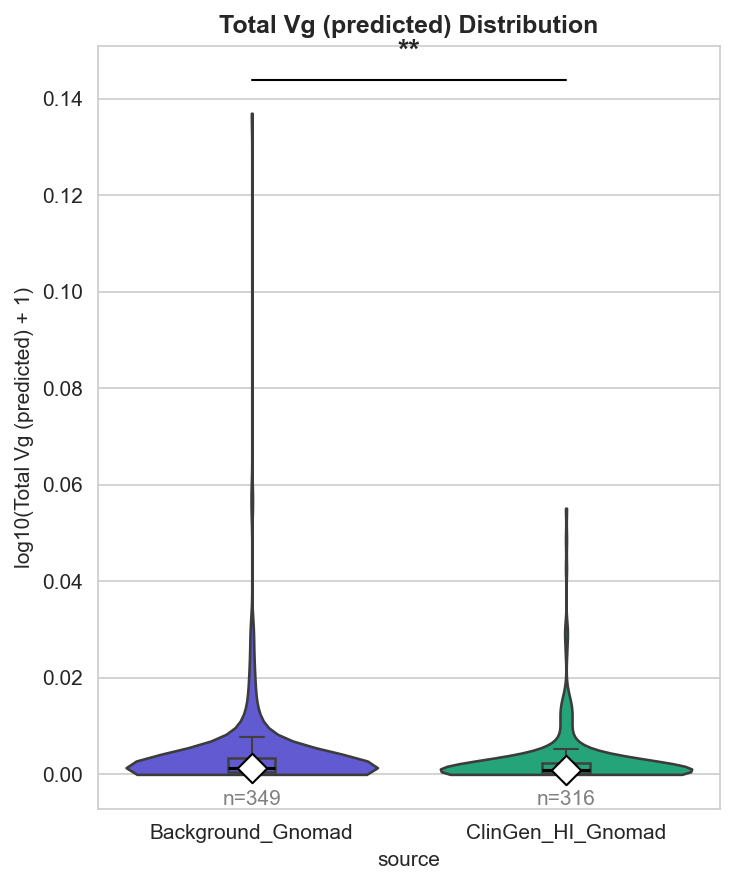

In [3]:
# --- Configuration & Naming ---
NAME_CL = 'ClinGen_HI_Gnomad'
NAME_BG = 'Background_Gnomad'
PLOT_ORDER = [NAME_BG, NAME_CL]

# Map new names to your existing config palette
PALETTE = {
    NAME_BG: SOURCE_PALETTE['background'],
    NAME_CL: SOURCE_PALETTE['clingen']
}

# --- Data Loading & Prep (Polars) ---
# Scan, tag with correct names, and combine
lf_cl = pl.scan_parquet(GENE_PATHS['clingen']).with_columns(pl.lit(NAME_CL).alias('source'))
lf_bg = pl.scan_parquet(GENE_PATHS['background']).with_columns(pl.lit(NAME_BG).alias('source'))
df = pl.concat([lf_cl, lf_bg]).collect()

# Robust metric selection
metric_col = 'total_vg' if 'total_vg' in df.columns else 'vg_predicted'
label = 'Total Vg (predicted)'

# Filter and Log-Transform if range is large
df_plot = df.select(['source', metric_col]).drop_nulls()
min_v, max_v = df_plot[metric_col].min(), df_plot[metric_col].max()
is_log = max_v / (min_v + 1e-9) > 100

if is_log:
    df_plot = df_plot.with_columns((pl.col(metric_col) + 1).log10().alias('plot_val'))
    ylabel = f'log10({label} + 1)'
else:
    df_plot = df_plot.with_columns(pl.col(metric_col).alias('plot_val'))
    ylabel = label

# --- Statistics (Mann-Whitney U) ---
groups = df_plot.partition_by("source", as_dict=True)

# polars partition_by returns tuple keys when as_dict=True
vals_bg = groups[(NAME_BG,)]['plot_val'].to_numpy()
vals_cl = groups[(NAME_CL,)]['plot_val'].to_numpy()

u_res = stats.mannwhitneyu(vals_bg, vals_cl, alternative='two-sided')
U, pval = u_res.statistic, u_res.pvalue
r_rb = 1 - (2 * U) / (len(vals_bg) * len(vals_cl))

if pval < 0.001: sig = '***'
elif pval < 0.01: sig = '**'
elif pval < 0.05: sig = '*'
else: sig = 'ns'

pdf = df_plot.to_pandas()

with autosave('clingen_vs_background_total_vg'):
    plt.figure(figsize=(5, 6))
    
    ax = sns.violinplot(data=pdf, x='source', y='plot_val', order=PLOT_ORDER, 
                        palette=PALETTE, hue='source', legend=False, cut=0, inner=None)
    
    sns.boxplot(data=pdf, x='source', y='plot_val', order=PLOT_ORDER, width=0.15,
                showcaps=True, boxprops={'facecolor': 'none', 'lw': 1.2},
                showfliers=False, medianprops={'color': 'black', 'lw': 1.5}, legend=False)
    
    # Medians (Diamond marker)
    ax.scatter([0, 1], [np.median(vals_bg), np.median(vals_cl)], 
               s=100, c='white', edgecolors='black', marker='D', zorder=10)

    y_max = pdf['plot_val'].max()
    y_range = y_max - pdf['plot_val'].min()
    line_y = y_max + 0.05 * y_range
    
    ax.plot([0, 1], [line_y, line_y], c='black', lw=1)
    ax.text(0.5, line_y + 0.02 * y_range, sig, ha='center', va='bottom', fontsize=14, fontweight='bold')
    
    ax.set_xticks([0, 1])
    ax.set_xticklabels(PLOT_ORDER)
    ax.text(0, ax.get_ylim()[0], f"n={len(vals_bg)}", ha='center', va='bottom', color='gray')
    ax.text(1, ax.get_ylim()[0], f"n={len(vals_cl)}", ha='center', va='bottom', color='gray')

    ax.set_ylabel(ylabel)
    ax.set_title(f'{label} Distribution', fontsize=12, fontweight='bold')
    plt.tight_layout()

console = Console()
stats_table = df_plot.group_by('source').agg([
    pl.len().alias('n'), pl.col('plot_val').mean().alias('mean'),
    pl.col('plot_val').median().alias('median'), pl.col('plot_val').std().alias('std')
])

t = Table(title=f"Statistics ({ylabel})")
t.add_column("Group"); t.add_column("n"); t.add_column("Mean"); t.add_column("Median")
for row in stats_table.iter_rows():
    t.add_row(row[0], str(row[1]), f"{row[2]:.3f}", f"{row[3]:.3f}")

console.print(t)
console.print(Panel(f"Mann-Whitney U: p={pval:.3e} | R={r_rb:.4f} ({sig})", title="Test Result"))

[save_plot] Saved: interactive_density_pivot_promoter_vs_downstream_01022026_2347.pdf
[save_plot] Saved: interactive_density_pivot_promoter_vs_downstream_01022026_2347.svg


                          Regional Density Statistics                          
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Region                            ┃ n (Bg/Cl) ┃ P-value   ┃ Effect Size (R) ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ Promoter Core (-200bp to +200bp)  │ 349/316   │ 5.979e-04 │ 0.1537          │
│ Downstream Proximal (TSS to +2kb) │ 349/316   │ 3.609e-09 │ 0.2644          │
└───────────────────────────────────┴───────────┴───────────┴─────────────────┘

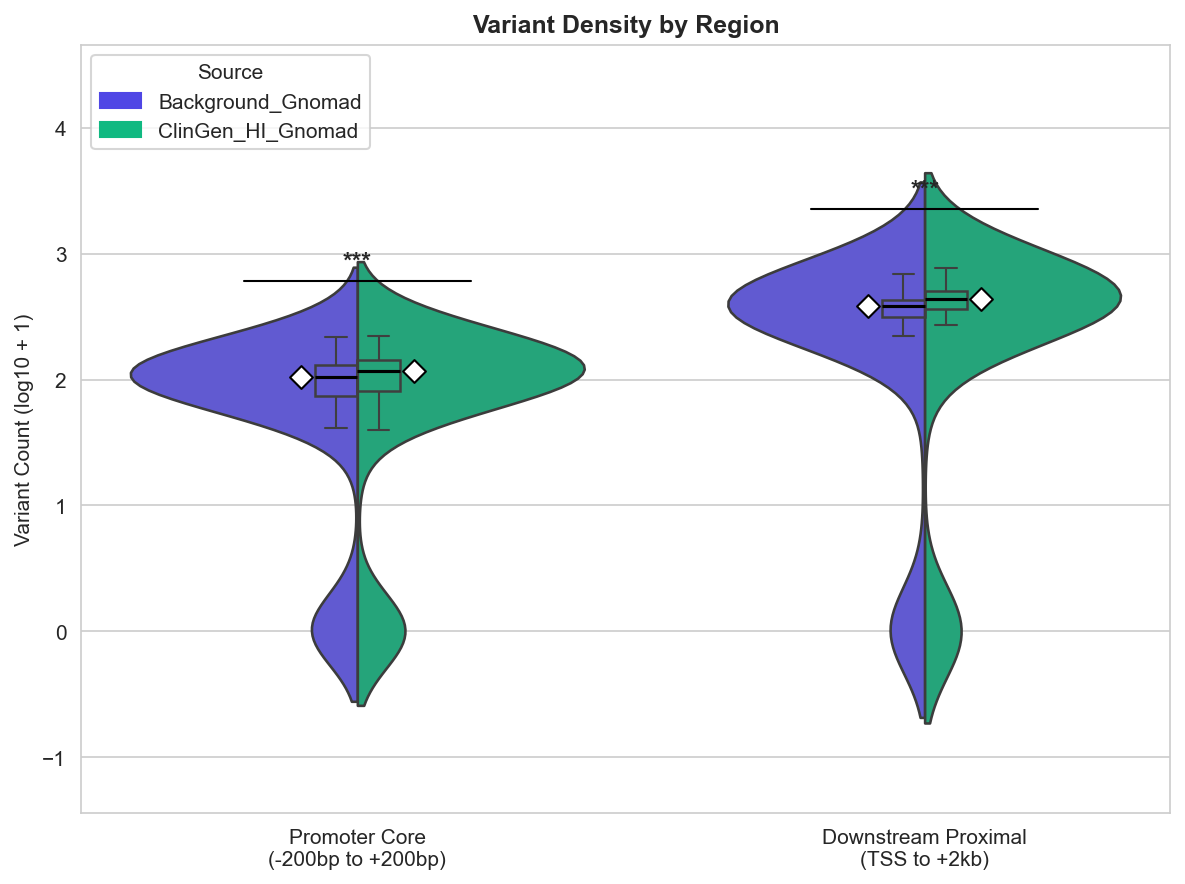

In [4]:
# --- Configuration ---
NAME_CL = 'ClinGen_HI_Gnomad'
NAME_BG = 'Background_Gnomad'
PLOT_ORDER = [NAME_BG, NAME_CL]

PALETTE = {
    NAME_BG: SOURCE_PALETTE['background'],
    NAME_CL: SOURCE_PALETTE['clingen']
}

# Mapping columns to Display Labels with Definitions
METRICS = {
    'n_variants_promoter_core': 'Promoter Core\n(-200bp to +200bp)',
    'n_variants_down_proximal': 'Downstream Proximal\n(TSS to +2kb)' 
}

# --- Data Loading & Pivoting (Polars) ---
lf_cl = pl.scan_parquet(GENE_PATHS['clingen']).with_columns(pl.lit(NAME_CL).alias('source'))
lf_bg = pl.scan_parquet(GENE_PATHS['background']).with_columns(pl.lit(NAME_BG).alias('source'))

df_long = (
    pl.concat([lf_cl, lf_bg])
    .select(['source'] + list(METRICS.keys()))
    .unpivot(
        index='source', 
        on=list(METRICS.keys()), 
        variable_name='metric_raw', 
        value_name='count'
    )
    .with_columns([
        (pl.col('count') + 1).log10().alias('plot_val'),
        pl.col('metric_raw').replace(METRICS).alias('Region')
    ])
    .collect()
)

pdf = df_long.to_pandas()

# --- Visualization ---
with autosave('density_pivot_promoter_vs_downstream'):
    fig, ax = plt.subplots(figsize=(8, 6))

    # Violin: cut=2 extends tails
    sns.violinplot(
        data=pdf, x='Region', y='plot_val', hue='source',
        split=True, inner=None, cut=2, bw_adjust=1.2,
        order=list(METRICS.values()), hue_order=PLOT_ORDER,
        palette=PALETTE, ax=ax, legend=False
    )

    # Boxplot Overlay
    sns.boxplot(
        data=pdf, x='Region', y='plot_val', hue='source',
        order=list(METRICS.values()), hue_order=PLOT_ORDER,
        width=0.15, showcaps=True,
        boxprops={'facecolor': 'none', 'lw': 1.2},
        showfliers=False,
        medianprops={'color': 'black', 'lw': 1.5},
        ax=ax, legend=False
    )

    # Stats Annotation Loop
    regions = list(METRICS.values())
    y_max_global = pdf['plot_val'].max()
    y_min_global = pdf['plot_val'].min()
    y_range = y_max_global - y_min_global
    
    stats_results = []

    for i, region in enumerate(regions):
        region_data = df_long.filter(pl.col('Region') == region)
        
        # Partition data for stats
        groups = region_data.partition_by("source", as_dict=True)
        vals_bg = groups.get((NAME_BG,), pl.DataFrame())['plot_val'].to_numpy()
        vals_cl = groups.get((NAME_CL,), pl.DataFrame())['plot_val'].to_numpy()

        if len(vals_bg) == 0 or len(vals_cl) == 0: continue

        # Mann-Whitney U
        u_res = stats.mannwhitneyu(vals_bg, vals_cl, alternative='two-sided')
        p_val = u_res.pvalue
        r_rb = 1 - (2 * u_res.statistic) / (len(vals_bg) * len(vals_cl))

        if p_val < 0.001: sig = '***'
        elif p_val < 0.01: sig = '**'
        elif p_val < 0.05: sig = '*'
        else: sig = 'ns'

        # Draw Lines & Text
        # FIXED: Increased buffer significantly (0.15 * range) to clear the long violin tail
        local_max = region_data['plot_val'].max()
        line_y = local_max + 0.15 * y_range
        text_y = line_y + 0.02 * y_range
        
        ax.plot([i - 0.2, i + 0.2], [line_y, line_y], c='black', lw=1)
        ax.text(i, text_y, sig, ha='center', va='bottom', fontsize=12, fontweight='bold')
        
        # Medians (Diamond Markers)
        ax.scatter(i - 0.1, np.median(vals_bg), s=60, c='white', edgecolors='black', marker='D', zorder=10)
        ax.scatter(i + 0.1, np.median(vals_cl), s=60, c='white', edgecolors='black', marker='D', zorder=10)

        stats_results.append((region.replace('\n', ' '), len(vals_bg), len(vals_cl), p_val, r_rb))

    # Labels
    ax.set_ylabel('Variant Count (log10 + 1)')
    ax.set_xlabel('')
    ax.set_title('Variant Density by Region', fontweight='bold')
    
    # Legend
    handles = [plt.Rectangle((0,0),1,1, color=PALETTE[n]) for n in PLOT_ORDER]
    ax.legend(handles, PLOT_ORDER, title='Source', loc='upper left')
    
    # FIXED: Explicitly expand Y-limits to give room for tails (bottom) and annotations (top)
    ymin, ymax = ax.get_ylim()
    # Subtracting/Adding 15-20% of range to limits
    ax.set_ylim(ymin - 0.5, ymax + 0.8)
    
    plt.tight_layout()

# --- Reporting ---
console = Console()
t = Table(title="Regional Density Statistics")
t.add_column("Region")
t.add_column("n (Bg/Cl)")
t.add_column("P-value")
t.add_column("Effect Size (R)")

for res in stats_results:
    t.add_row(res[0], f"{res[1]}/{res[2]}", f"{res[3]:.3e}", f"{res[4]:.4f}")

console.print(t)

[save_plot] Saved: interactive_density_pivot_counts_and_effects_01022026_2347.pdf
[save_plot] Saved: interactive_density_pivot_counts_and_effects_01022026_2347.svg


                             Regional Statistics                              
┏━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Type                     ┃ Region            ┃ P-value   ┃ Effect Size (R) ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ Variant Density (Counts) │ Promoter Core     │ 5.979e-04 │ 0.1537          │
│ Variant Density (Counts) │ Downstream Prox   │ 3.609e-09 │ 0.2644          │
│ Mean Effect Size         │ Promoter Effect   │ nan       │ nan             │
│ Mean Effect Size         │ Downstream Effect │ nan       │ nan             │
└──────────────────────────┴───────────────────┴───────────┴─────────────────┘

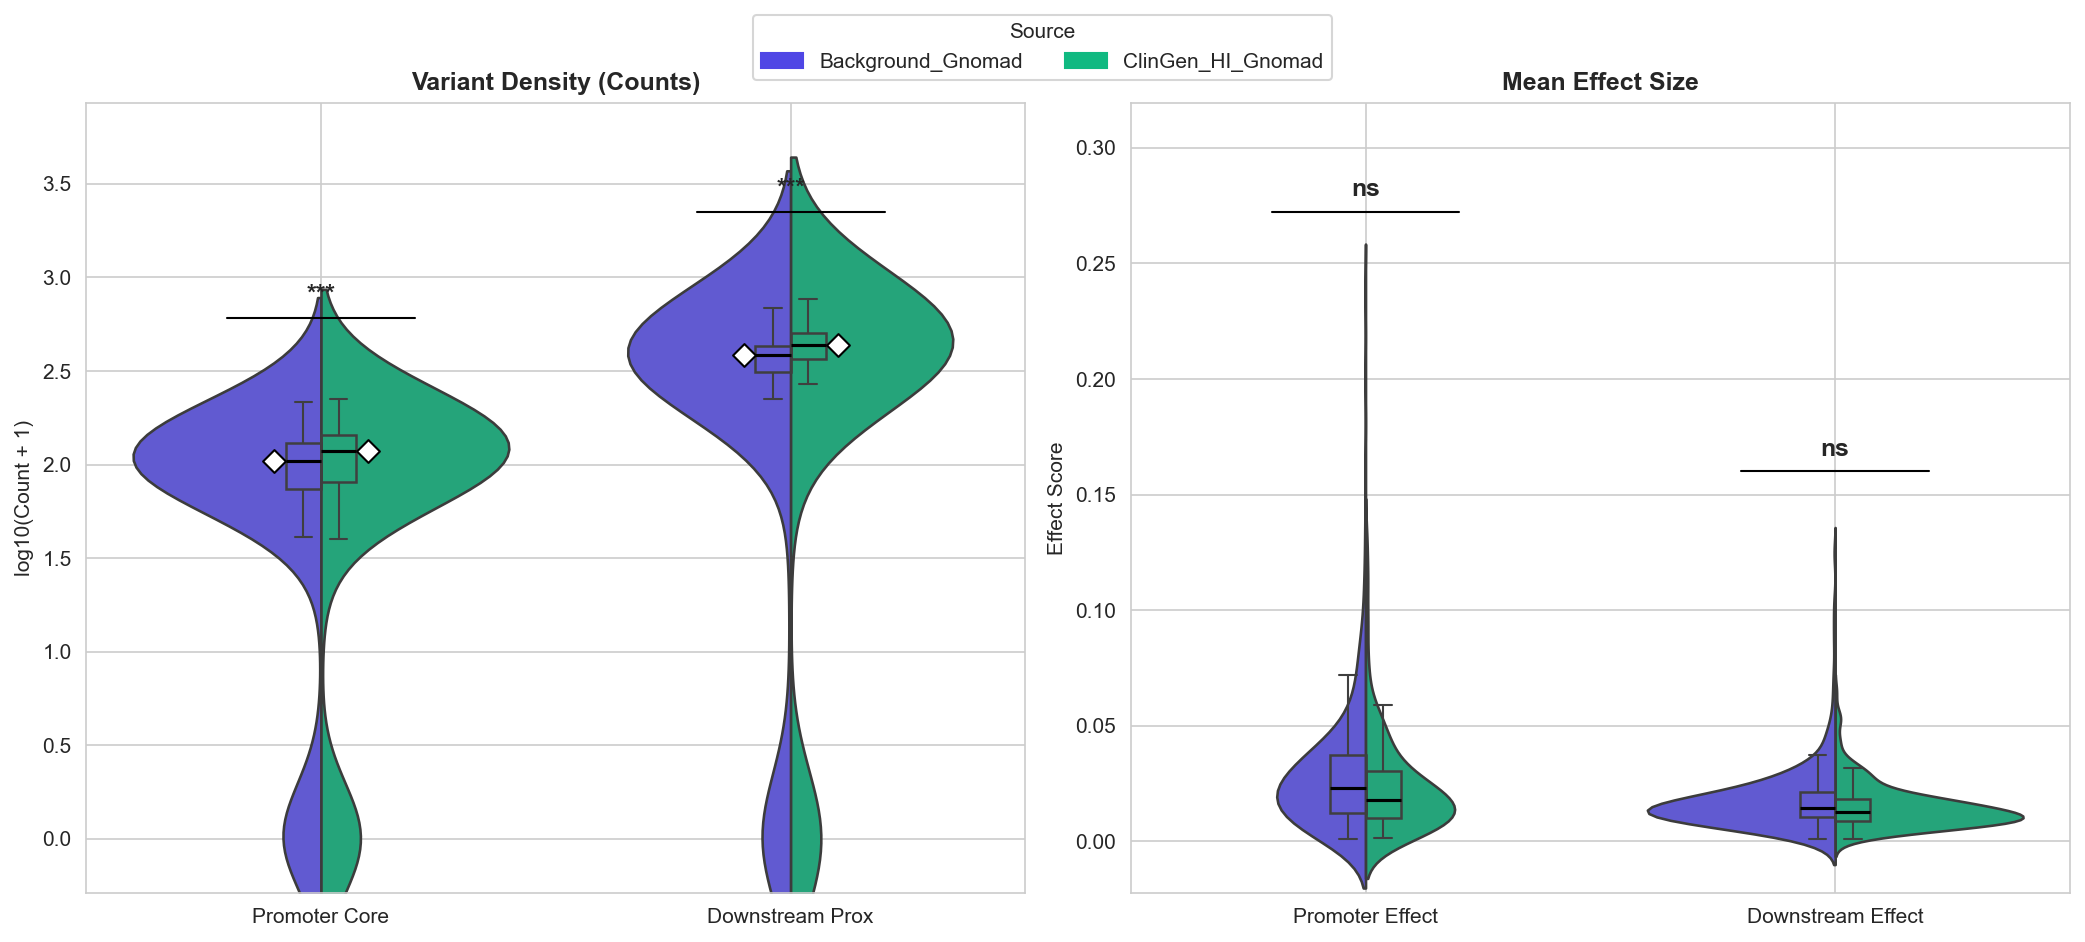

In [5]:
NAME_CL = 'ClinGen_HI_Gnomad'
NAME_BG = 'Background_Gnomad'
PLOT_ORDER = [NAME_BG, NAME_CL]

PALETTE = {
    NAME_BG: SOURCE_PALETTE['background'],
    NAME_CL: SOURCE_PALETTE['clingen']
}

METRICS_COUNTS = {
    'n_variants_promoter_core': 'Promoter Core',
    'n_variants_down_proximal': 'Downstream Prox'
}

METRICS_EFFECTS = {
    'mean_abs_promoter_core': 'Promoter Effect',
    'mean_abs_down_proximal': 'Downstream Effect'
}

def load_and_prep(metrics_map, log_scale=False):
    """
    Reduces redundancy: Loads, unpivots, and formats data for any metric set.
    """
    # Combine lazy frames
    lf = pl.concat([
        pl.scan_parquet(GENE_PATHS['clingen']).with_columns(pl.lit(NAME_CL).alias('source')),
        pl.scan_parquet(GENE_PATHS['background']).with_columns(pl.lit(NAME_BG).alias('source'))
    ])
    
    # Select only needed columns + source
    cols = ['source'] + list(metrics_map.keys())
    
    q = (
        lf.select(cols)
        .unpivot(index='source', on=list(metrics_map.keys()), variable_name='metric_raw', value_name='val')
        .with_columns(pl.col('metric_raw').replace(metrics_map).alias('Region'))
    )

    # Optional Log Transformation
    if log_scale:
        q = q.with_columns((pl.col('val') + 1).log10().alias('plot_val'))
    else:
        q = q.with_columns(pl.col('val').alias('plot_val'))
        
    return q.collect().to_pandas()

def plot_split_violin(ax, data, title, ylabel, order_list):
    region_map = {name: i for i, name in enumerate(order_list)}
    plot_data = data.copy()
    plot_data['x_idx'] = plot_data['Region'].map(region_map)
    
    # 2. Seaborn Plotting (using numeric x_idx)
    sns.violinplot(
        data=plot_data, x='x_idx', y='plot_val', hue='source',
        split=True, inner=None, cut=2, bw_adjust=1.2,
        hue_order=PLOT_ORDER, palette=PALETTE, ax=ax, legend=False,
        native_scale=True
    )
    
    sns.boxplot(
        data=plot_data, x='x_idx', y='plot_val', hue='source',
        hue_order=PLOT_ORDER, width=0.15, showcaps=True,
        boxprops={'facecolor': 'none', 'lw': 1.2},
        showfliers=False, medianprops={'color': 'black', 'lw': 1.5},
        ax=ax, native_scale=True, legend=False
    )

    # 3. Restore String Labels
    ax.set_xticks(range(len(order_list)))
    ax.set_xticklabels(order_list)
    ax.set_xlim(-0.5, len(order_list) - 0.5)

    # 4. Stats & Annotations
    y_range = plot_data['plot_val'].max() - plot_data['plot_val'].min()
    stats_list = []

    for i, region in enumerate(order_list):
        # Filter by original string label
        region_df = plot_data[plot_data['Region'] == region]
        vals_bg = region_df[region_df['source'] == NAME_BG]['plot_val'].values
        vals_cl = region_df[region_df['source'] == NAME_CL]['plot_val'].values

        if len(vals_bg) == 0 or len(vals_cl) == 0: continue

        # Mann-Whitney U
        u_res = stats.mannwhitneyu(vals_bg, vals_cl, alternative='two-sided')
        p_val = u_res.pvalue
        r_rb = 1 - (2 * u_res.statistic) / (len(vals_bg) * len(vals_cl))

        # Significance marker
        if p_val < 0.001: sig = '***'
        elif p_val < 0.01: sig = '**'
        elif p_val < 0.05: sig = '*'
        else: sig = 'ns'

        # Dynamic positioning
        local_max = region_df['plot_val'].max()
        line_y = local_max + 0.15 * y_range
        text_y = line_y + 0.02 * y_range
        
        # Draw annotation
        ax.plot([i - 0.2, i + 0.2], [line_y, line_y], c='black', lw=1)
        ax.text(i, text_y, sig, ha='center', va='bottom', fontsize=12, fontweight='bold')
        
        # Medians
        ax.scatter(i - 0.1, np.median(vals_bg), s=60, c='white', edgecolors='black', marker='D', zorder=10)
        ax.scatter(i + 0.1, np.median(vals_cl), s=60, c='white', edgecolors='black', marker='D', zorder=10)
        
        stats_list.append((title, region, p_val, r_rb))

    # Styling
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel(ylabel)
    ax.set_xlabel('')
    ax.set_ylim(plot_data['plot_val'].min() - (0.1 * y_range), plot_data['plot_val'].max() + (0.35 * y_range))
    
    return stats_list

with autosave('density_pivot_counts_and_effects'):
    pdf_counts = load_and_prep(METRICS_COUNTS, log_scale=True)
    pdf_effects = load_and_prep(METRICS_EFFECTS, log_scale=False)

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    # Plot 1: Counts
    stats_counts = plot_split_violin(
        axes[0], pdf_counts, 
        'Variant Density (Counts)', 'log10(Count + 1)', list(METRICS_COUNTS.values())
    )
    
    # Plot 2: Effects
    stats_effects = plot_split_violin(
        axes[1], pdf_effects, 
        'Mean Effect Size', 'Effect Score', list(METRICS_EFFECTS.values())
    )

    # Common Legend
    handles = [plt.Rectangle((0,0),1,1, color=PALETTE[n]) for n in PLOT_ORDER]
    fig.legend(handles, PLOT_ORDER, loc='upper center', bbox_to_anchor=(0.5, 1.05), ncol=2, title='Source')
    
    plt.tight_layout()

# --- Reporting ---
console = Console()
all_stats = stats_counts + stats_effects
t = Table(title="Regional Statistics")
t.add_column("Type")
t.add_column("Region")
t.add_column("P-value")
t.add_column("Effect Size (R)")

for res in all_stats:
    t.add_row(res[0], res[1], f"{res[2]:.3e}", f"{res[3]:.4f}")

console.print(t)

# The Spatial Shift (Promoter vs. Enhancer)#

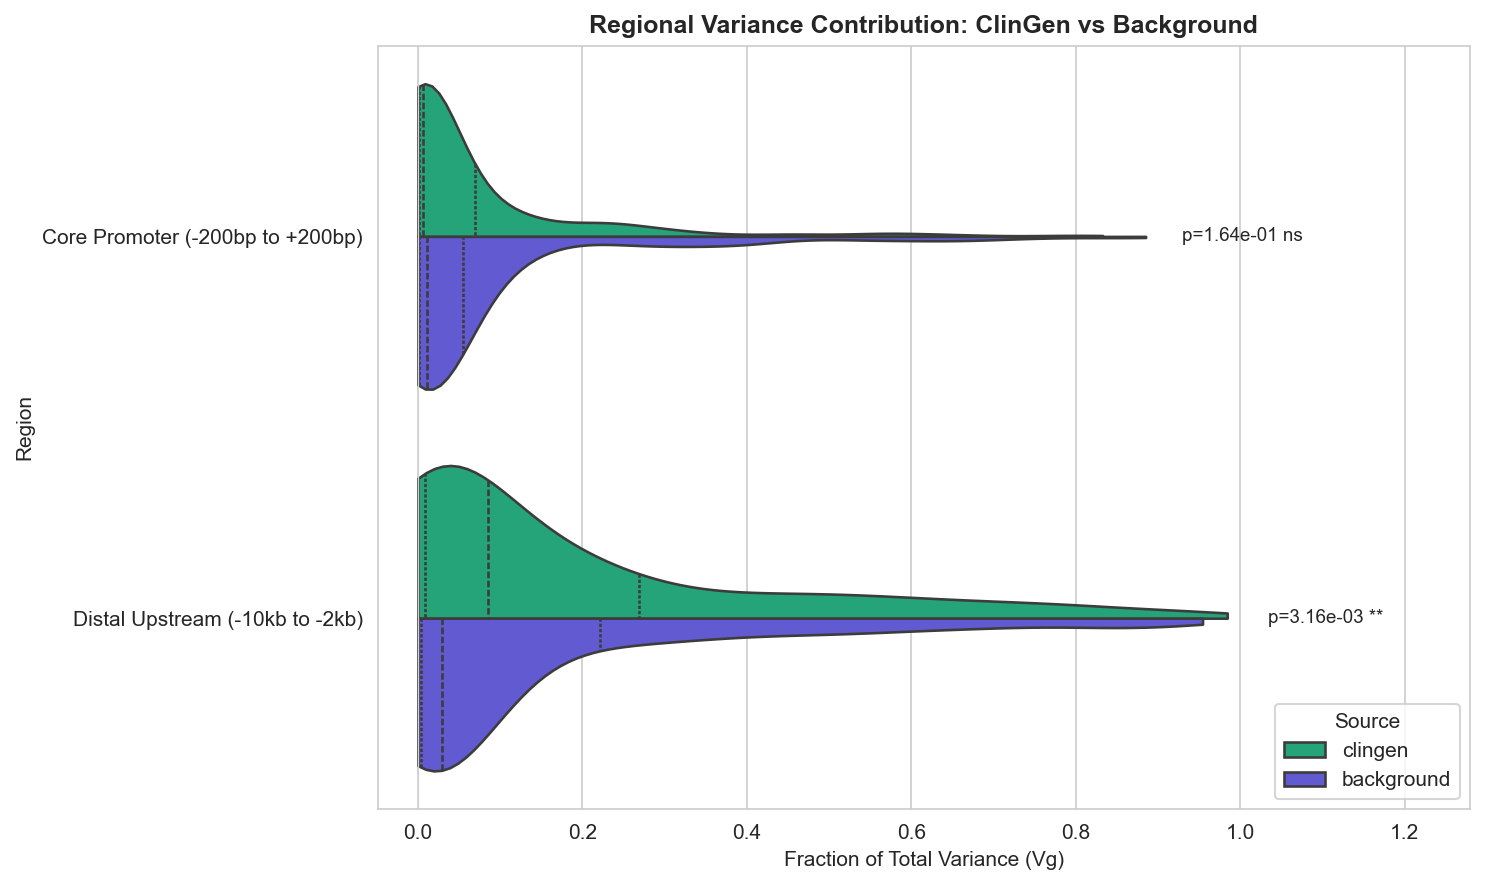

                Regional Fraction Statistics (Mann-Whitney U)                 
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━┓
┃ Region                           ┃ P-value   ┃ Effect Size (R) ┃ N (Cl/Bg) ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━┩
│ Core Promoter (-200bp to +200bp) │ 1.638e-01 │ 0.0624          │ 316/349   │
│ Distal Upstream (-10kb to -2kb)  │ 3.155e-03 │ -0.1322         │ 316/349   │
└──────────────────────────────────┴───────────┴─────────────────┴───────────┘

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
import polars as pl
import pandas as pd
import numpy as np
from scipy.stats import mannwhitneyu
from rich.console import Console
from rich.table import Table

lf_cl = pl.scan_parquet(CLINGEN_GENE).with_columns(pl.lit('clingen').alias('source'))
lf_bg = pl.scan_parquet(BG_GENE).with_columns(pl.lit('background').alias('source'))

cols = ['source', 'vg_promoter_core', 'vg_distal_upstream']
total_col = 'total_vg' if 'total_vg' in lf_cl.collect_schema().names() else 'vg_predicted'
cols.append(total_col)

df = pl.concat([lf_cl, lf_bg]).select(cols).collect().to_pandas()
df = df[(df[total_col] > 0) & df[total_col].notnull()].copy()

df['Core Promoter (-200bp to +200bp)'] = df['vg_promoter_core'] / df[total_col]
df['Distal Upstream (-10kb to -2kb)'] = df['vg_distal_upstream'] / df[total_col]

plot_long = df.melt(
    id_vars=['source'], 
    value_vars=['Core Promoter (-200bp to +200bp)', 'Distal Upstream (-10kb to -2kb)'], 
    var_name='Region', value_name='Fraction'
).dropna()

plt.figure(figsize=(10, 6))
hue_order = ['clingen', 'background']
palette = {k: SOURCE_PALETTE[k] for k in hue_order}

ax = sns.violinplot(
    data=plot_long, x='Fraction', y='Region', hue='source', hue_order=hue_order,
    split=True, inner='quartile', palette=palette, cut=0, density_norm='width'
)

regions = plot_long['Region'].unique()
y_ticks = {l.get_text(): l.get_position()[1] for l in ax.get_yticklabels()}
stats_res = []

for reg in regions:
    sub = plot_long[plot_long['Region'] == reg]
    vals_cl = sub[sub['source'] == 'clingen']['Fraction'].values
    vals_bg = sub[sub['source'] == 'background']['Fraction'].values
    
    if len(vals_cl) > 0 and len(vals_bg) > 0:
        res = mannwhitneyu(vals_cl, vals_bg, alternative='two-sided')
        r_rb = 1.0 - (2.0 * res.statistic) / (len(vals_cl) * len(vals_bg))
        stats_res.append((reg, res.pvalue, r_rb, len(vals_cl), len(vals_bg)))
        
        sig = '***' if res.pvalue < 0.001 else '**' if res.pvalue < 0.01 else '*' if res.pvalue < 0.05 else 'ns'
        ax.text(sub['Fraction'].max() * 1.05, y_ticks[reg], f"p={res.pvalue:.2e} {sig}", va='center', fontsize=9)

plt.axvline(0, color='lightgray', lw=0.6)
plt.title('Regional Variance Contribution: ClinGen vs Background', fontweight='bold')
plt.xlabel('Fraction of Total Variance (Vg)')
plt.xlim(right=plot_long['Fraction'].max() * 1.3)
plt.legend(title='Source', loc='lower right')
plt.tight_layout()
autosave('split_violin_promoter_distal_fractions')
plt.show()

console = Console()
t = Table(title="Regional Fraction Statistics (Mann-Whitney U)")
t.add_column("Region"); t.add_column("P-value"); t.add_column("Effect Size (R)"); t.add_column("N (Cl/Bg)")

for r, p, rb, nc, nb in stats_res:
    t.add_row(r, f"{p:.3e}", f"{rb:.4f}", f"{nc}/{nb}")
console.print(t)

Promoter Core: ClinGen is lower (0.40x). (The core promoter is rigid/conserved).
Distal Upstream: ClinGen is higher

In [7]:
clingen = pl.read_parquet(CLINGEN_GENE).with_columns(pl.lit('clingen').alias('source'))
background = pl.read_parquet(BG_GENE).with_columns(pl.lit('background').alias('source'))
combined = pl.concat([clingen, background]).to_pandas()

variance_metrics = [
    ('vg_predicted', 'total vg'),
    ('vg_distal_upstream', 'vg distal upstream'),
    ('n_variants_distal_upstream', 'n variants distal upstream'),
    ('mean_abs_distal_upstream', 'mean effect distal upstream'),
    ('vg_proximal_upstream', 'vg proximal upstream'),
    ('n_variants_proximal_upstream', 'n variants proximal upstream'),
    ('mean_abs_proximal_upstream', 'mean effect proximal upstream'),
    ('vg_promoter_core', 'vg promoter core'),
    ('n_variants_promoter_core', 'n variants promoter core'),
    ('mean_abs_promoter_core', 'mean effect promoter core'),
    ('vg_down_proximal', 'vg down proximal'),
    ('n_variants_down_proximal', 'n variants down proximal'),
    ('mean_abs_down_proximal', 'mean effect down proximal'),
    ('vg_down_distal', 'vg down distal'),
    ('n_variants_down_distal', 'n variants down distal'),
    ('mean_abs_down_distal', 'mean effect down distal'),
]

available = [(c, l) for c, l in variance_metrics if c in combined.columns]
if not available: raise ValueError("No metrics found.")

RESULTS_DIR = Path(PROJECT_ROOT) / "results"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

n_rows = math.ceil(len(available) / 3)
fig, axes = plt.subplots(n_rows, 3, figsize=(18, 3.8 * n_rows), constrained_layout=True)
axes_flat = axes.flatten()

pal = {k: SOURCE_PALETTE[k] for k in ['clingen', 'background']}
summary_rows = []

for idx, (col, label) in enumerate(available):
    ax = axes_flat[idx]
    df = combined[[col, 'source']].dropna().copy()
    if df.empty: continue
    
    vals = df[col]
    log_scale = (vals.max() / (vals.min() + 1e-9)) > 100
    df['plot_val'] = np.log10(vals + 1) if log_scale else vals
    ylabel = f'log10({label} + 1)' if log_scale else label
    df['dummy'] = label

    sns.violinplot(data=df, x='dummy', y='plot_val', hue='source', split=True, inner=None,
                   hue_order=['clingen', 'background'], palette=pal, ax=ax, cut=0)
    sns.boxplot(data=df, x='dummy', y='plot_val', width=0.12, showfliers=False, ax=ax,
                boxprops={'facecolor':'none'}, medianprops={'color':'black'})

    cl_vals = df[df['source'] == 'clingen']['plot_val']
    bg_vals = df[df['source'] == 'background']['plot_val']
    
    if len(cl_vals) and len(bg_vals):
        res = mannwhitneyu(cl_vals, bg_vals)
        p, r_rb = res.pvalue, 1 - (2 * res.statistic) / (len(cl_vals) * len(bg_vals))
        
        y_max = df['plot_val'].max()
        y_min = df['plot_val'].min()
        y_range = (y_max - y_min) or 1
        sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'ns'
        
        ax.plot([ax.get_xlim()[0]*0.2, ax.get_xlim()[1]*0.2], [y_max + 0.06*y_range]*2, 'k-', lw=1)
        ax.text(0, y_max + 0.12*y_range, sig, ha='center', va='bottom', fontweight='bold')
        
        ax.scatter([-0.1], [cl_vals.median()], c='white', edgecolors='k', marker='D', zorder=10)
        ax.scatter([0.1], [bg_vals.median()], c='white', edgecolors='k', marker='D', zorder=10)
        
        summary_rows.append({'label': label, 'n_cl': len(cl_vals), 'n_bg': len(bg_vals), 
                             'med_cl': cl_vals.median(), 'med_bg': bg_vals.median(), 'p': p, 'r_rb': r_rb})

    ax.set(title=label, xlabel='', ylabel=ylabel)
    ax.grid(axis='y', alpha=0.2)

for ax in axes_flat[len(available):]: ax.set_visible(False)
autosave('split_violins_3cols')
plt.show()

summary_df = pd.DataFrame(summary_rows)
summary_df.to_csv(RESULTS_DIR / 'variance_stats.csv', index=False)

console = Console()
t = Table(title="Top Metrics by Significance")
for c in ['label', 'n_cl', 'n_bg', 'med_cl', 'med_bg', 'p', 'r_rb']: t.add_column(c)
for _, r in summary_df.sort_values('p').head(10).iterrows():
    t.add_row(r['label'], str(r['n_cl']), str(r['n_bg']), f"{r['med_cl']:.3g}", f"{r['med_bg']:.3g}", f"{r['p']:.2e}", f"{r['r_rb']:.3f}")
console.print(t)

NameError: name 'math' is not defined

# Spatial (Distal Shift)

Goal is to see where this dampening happens.

Logic: "Since promoters are naturally 'high impact' regions (risky), how do essential genes maintain complexity without breaking?"

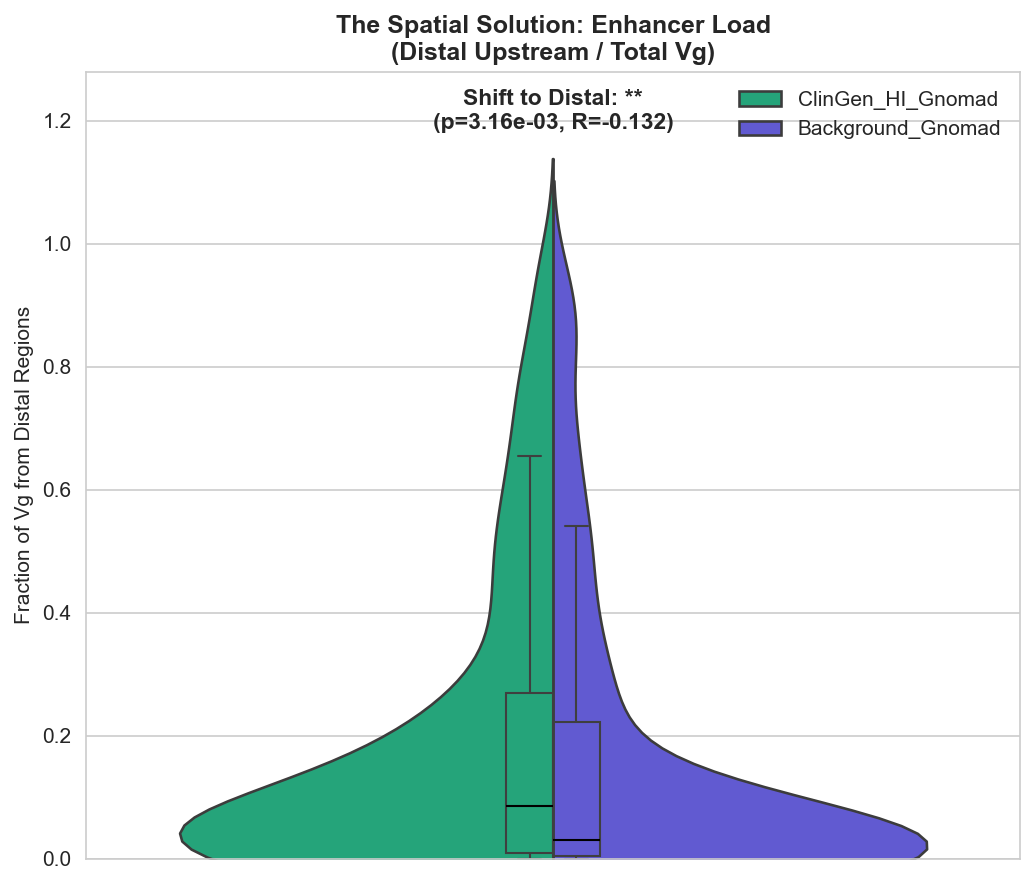

Median Load | ClinGen_HI_Gnomad: 0.085 | Background_Gnomad: 0.029


In [ ]:
NAME_CL = 'ClinGen_HI_Gnomad'
NAME_BG = 'Background_Gnomad'

clingen = pl.read_parquet(CLINGEN_GENE).with_columns(pl.lit(NAME_CL).alias('source'))
background = pl.read_parquet(BG_GENE).with_columns(pl.lit(NAME_BG).alias('source'))
df = pl.concat([clingen, background]).to_pandas()

# Metric Calculation
total_col = 'total_vg' if 'total_vg' in df.columns else 'vg_predicted'
distal_col = 'vg_distal_upstream'

df = df[df[total_col] > 0].copy()
df['Enhancer Load'] = df[distal_col] / df[total_col]
df = df.dropna(subset=['Enhancer Load', 'source'])

cl_vals = df[df['source'] == NAME_CL]['Enhancer Load']
bg_vals = df[df['source'] == NAME_BG]['Enhancer Load']
res = mannwhitneyu(cl_vals, bg_vals, alternative='two-sided')
r_rb = 1 - (2 * res.statistic) / (len(cl_vals) * len(bg_vals))
sig = '***' if res.pvalue < 0.001 else '**' if res.pvalue < 0.01 else '*' if res.pvalue < 0.05 else 'ns'

plt.figure(figsize=(7, 6))
# Map new specific names to existing palette colors
pal = {NAME_CL: SOURCE_PALETTE['clingen'], NAME_BG: SOURCE_PALETTE['background']}

ax = sns.violinplot(
    data=df, x=np.zeros(len(df)), y='Enhancer Load', hue='source',
    split=True, inner=None, hue_order=[NAME_CL, NAME_BG], 
    palette=pal, cut=2  # cut=2 lets tails extend
)

sns.boxplot(
    data=df, x=np.zeros(len(df)), y='Enhancer Load', hue='source', 
    hue_order=[NAME_CL, NAME_BG], width=0.1, showfliers=False, 
    boxprops={'facecolor':'none', 'lw':1}, medianprops={'color':'k'}, 
    ax=ax, legend=False
)

# Annotations & Styling
y_max = df['Enhancer Load'].max()
ax.text(0, y_max * 1.2, f"Shift to Distal: {sig}\n(p={res.pvalue:.2e}, R={r_rb:.3f})", 
        ha='center', va='bottom', fontweight='bold', fontsize=11)

ax.set_ylim(0, y_max * 1.3)
ax.set_title('The Spatial Solution: Enhancer Load\n(Distal Upstream / Total Vg)', fontweight='bold')
ax.set_ylabel('Fraction of Vg from Distal Regions')
ax.set_xticks([])

# Clean Legend (remove duplicates and title)
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[:2], labels[:2], title='', loc='upper right', frameon=False)

plt.tight_layout()
autosave('enhancer_load_distal_shift')
plt.show()

print(f"Median Load | {NAME_CL}: {cl_vals.median():.3f} | {NAME_BG}: {bg_vals.median():.3f}")

Distal variants naturally have lower effect sizes. By relying on distal enhancers, essential genes achieve the "High N, Low Mean Effect"

# The Subtypes (Clustering)

      Validation A: ClinGen Enrichment across the Gradient      
┏━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━┓
┃ Architecture         ┃ ClinGen % ┃ Background % ┃ Enrichment ┃
┡━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━━┩
│ Fragile (Bottom 25%) │     23.1% │        26.9% │      0.86x │
│ Mid-Low              │     25.3% │        24.6% │      1.03x │
│ Mid-High             │     24.4% │        25.5% │      0.96x │
│ Buffered (Top 25%)   │     27.2% │        22.9% │      1.19x │
└──────────────────────┴───────────┴──────────────┴────────────┘

                Validation B: Mechanism of the Extremes                 
┏━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━┓
┃ Group                ┃ N90 (Drivers) ┃ Effect Size (Mean) ┃ Total Vg ┃
┡━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━┩
│ Fragile (Bottom 25%) │          10.0 │            0.00768 │   0.0034 │
│ Buffered (Top 25%)   │          10.0 │            0.00703 │   0.0029 │
└──────────────────────┴───────────────┴────────────────────┴──────────┘

/var/folders/4k/lmr1c7ss61n50vqkw_40j0pm0000gn/T/ipykernel_12153/213943877.py:81: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


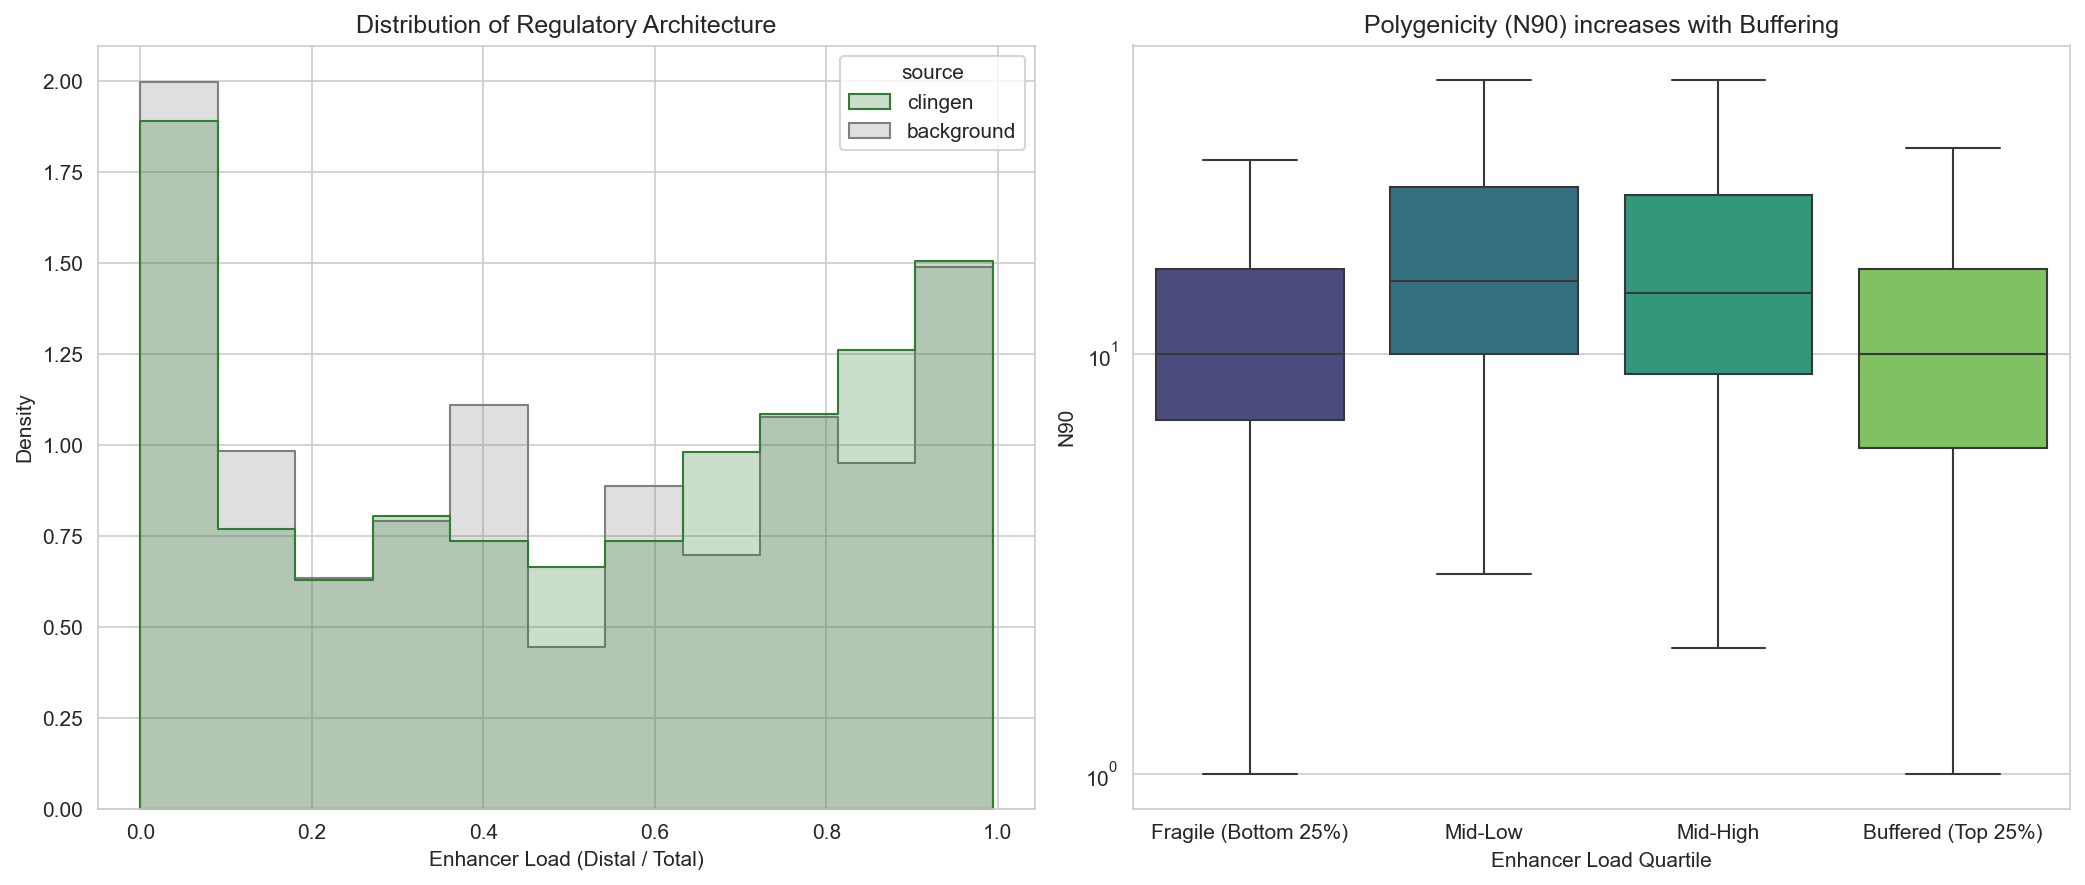

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import polars as pl
from rich.console import Console
from rich.table import Table

# --- 1. Preparation ---
# Re-load to ensure clean state
clingen = pl.read_parquet(CLINGEN_GENE).with_columns(pl.lit('clingen').alias('source'))
background = pl.read_parquet(BG_GENE).with_columns(pl.lit('background').alias('source'))
combined = pl.concat([clingen, background]).to_pandas()

df = combined.copy()
# Robust column selection based on your provided list
total_col = 'total_vg' if 'total_vg' in df.columns else 'vg_predicted'

# Calculate Features
df['vg_distal_sum'] = df['vg_distal_upstream'].fillna(0) + df['vg_down_distal'].fillna(0)

# Filter out zero-variance genes to avoid division errors
df = df[df[total_col] > 0].copy()
df['enhancer_load'] = df['vg_distal_sum'] / df[total_col]

# --- 2. The Gradient Split (Quartiles) ---
df['Architecture_Bin'] = pd.qcut(
    df['enhancer_load'], 
    q=4, 
    labels=['Fragile (Bottom 25%)', 'Mid-Low', 'Mid-High', 'Buffered (Top 25%)']
)

# --- 3. Validation A: Enrichment ---
console = Console()
ct_norm = pd.crosstab(df['Architecture_Bin'], df['source'], normalize='columns') * 100

tbl_a = Table(title="Validation A: ClinGen Enrichment across the Gradient")
tbl_a.add_column("Architecture", style="bold")
tbl_a.add_column("ClinGen %", justify="right", style="green")
tbl_a.add_column("Background %", justify="right", style="dim")
tbl_a.add_column("Enrichment", justify="right", style="magenta")

for bin_name in ['Fragile (Bottom 25%)', 'Mid-Low', 'Mid-High', 'Buffered (Top 25%)']:
    cl_pct = ct_norm.loc[bin_name, 'clingen']
    bg_pct = ct_norm.loc[bin_name, 'background']
    tbl_a.add_row(bin_name, f"{cl_pct:.1f}%", f"{bg_pct:.1f}%", f"{cl_pct/bg_pct:.2f}x")

console.print(tbl_a)

# --- 4. Validation B: Mechanism ---
# FIX: Use `total_col` variable instead of hardcoded 'total_vg' string
stats = df.groupby('Architecture_Bin', observed=True)[['N90', 'mean_abs_effect', total_col]].median()

tbl_b = Table(title="Validation B: Mechanism of the Extremes")
tbl_b.add_column("Group", style="bold")
tbl_b.add_column("N90 (Drivers)", justify="right")
tbl_b.add_column("Effect Size (Mean)", justify="right")
tbl_b.add_column("Total Vg", justify="right", style="cyan")

for bin_name in ['Fragile (Bottom 25%)', 'Buffered (Top 25%)']:
    row = stats.loc[bin_name]
    tbl_b.add_row(
        bin_name,
        f"{row['N90']:.1f}",
        f"{row['mean_abs_effect']:.5f}",
        f"{row[total_col]:.4f}"
    )
console.print(tbl_b)

# --- 5. Visualization ---
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: Density
sns.histplot(
    data=df, x='enhancer_load', hue='source', element="step", stat="density",
    common_norm=False, ax=axes[0], palette={'clingen': '#2E7D32', 'background': 'gray'}
)
axes[0].set_title('Distribution of Regulatory Architecture')
axes[0].set_xlabel('Enhancer Load (Distal / Total)')

# Plot 2: Boxplot
sns.boxplot(
    data=df, x='Architecture_Bin', y='N90', ax=axes[1], 
    palette="viridis", showfliers=False
)
axes[1].set_yscale('log')
axes[1].set_title('Polygenicity (N90) increases with Buffering')
axes[1].set_xlabel('Enhancer Load Quartile')

plt.tight_layout()
plt.show()

Loading and merging datasets...


                 Validation A: Where do Essential Genes Live?                 
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┓
┃ Architecture (Enhancer Load) ┃ ClinGen % ┃ Background % ┃ Enrichment Score ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━┩
│ Fragile (Bottom 25%)         │     23.1% │        26.9% │            0.86x │
│ Mid-Low                      │     25.3% │        24.6% │            1.03x │
│ Mid-High                     │     24.4% │        25.5% │            0.96x │
│ Buffered (Top 25%)           │     27.2% │        22.9% │            1.19x │
└──────────────────────────────┴───────────┴──────────────┴──────────────────┘

Interpretation: >1.0x means Essential genes prefer this architecture.

                  Validation B: The Mechanism of the Extremes                   
┏━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┓
┃ Group                ┃ N90 (Drivers) ┃ Effect Size (Mean) ┃ Total Vg (Noise) ┃
┡━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━┩
│ Fragile (Bottom 25%) │          10.0 │            0.00768 │          0.00340 │
│ Buffered (Top 25%)   │          10.0 │            0.00703 │          0.00288 │
└──────────────────────┴───────────────┴────────────────────┴──────────────────┘

Interpretation: Higher N90 = 'Sponge' (Dampening). Lower N90 = 'Laser' (Precision).

/var/folders/4k/lmr1c7ss61n50vqkw_40j0pm0000gn/T/ipykernel_12153/3177707578.py:101: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


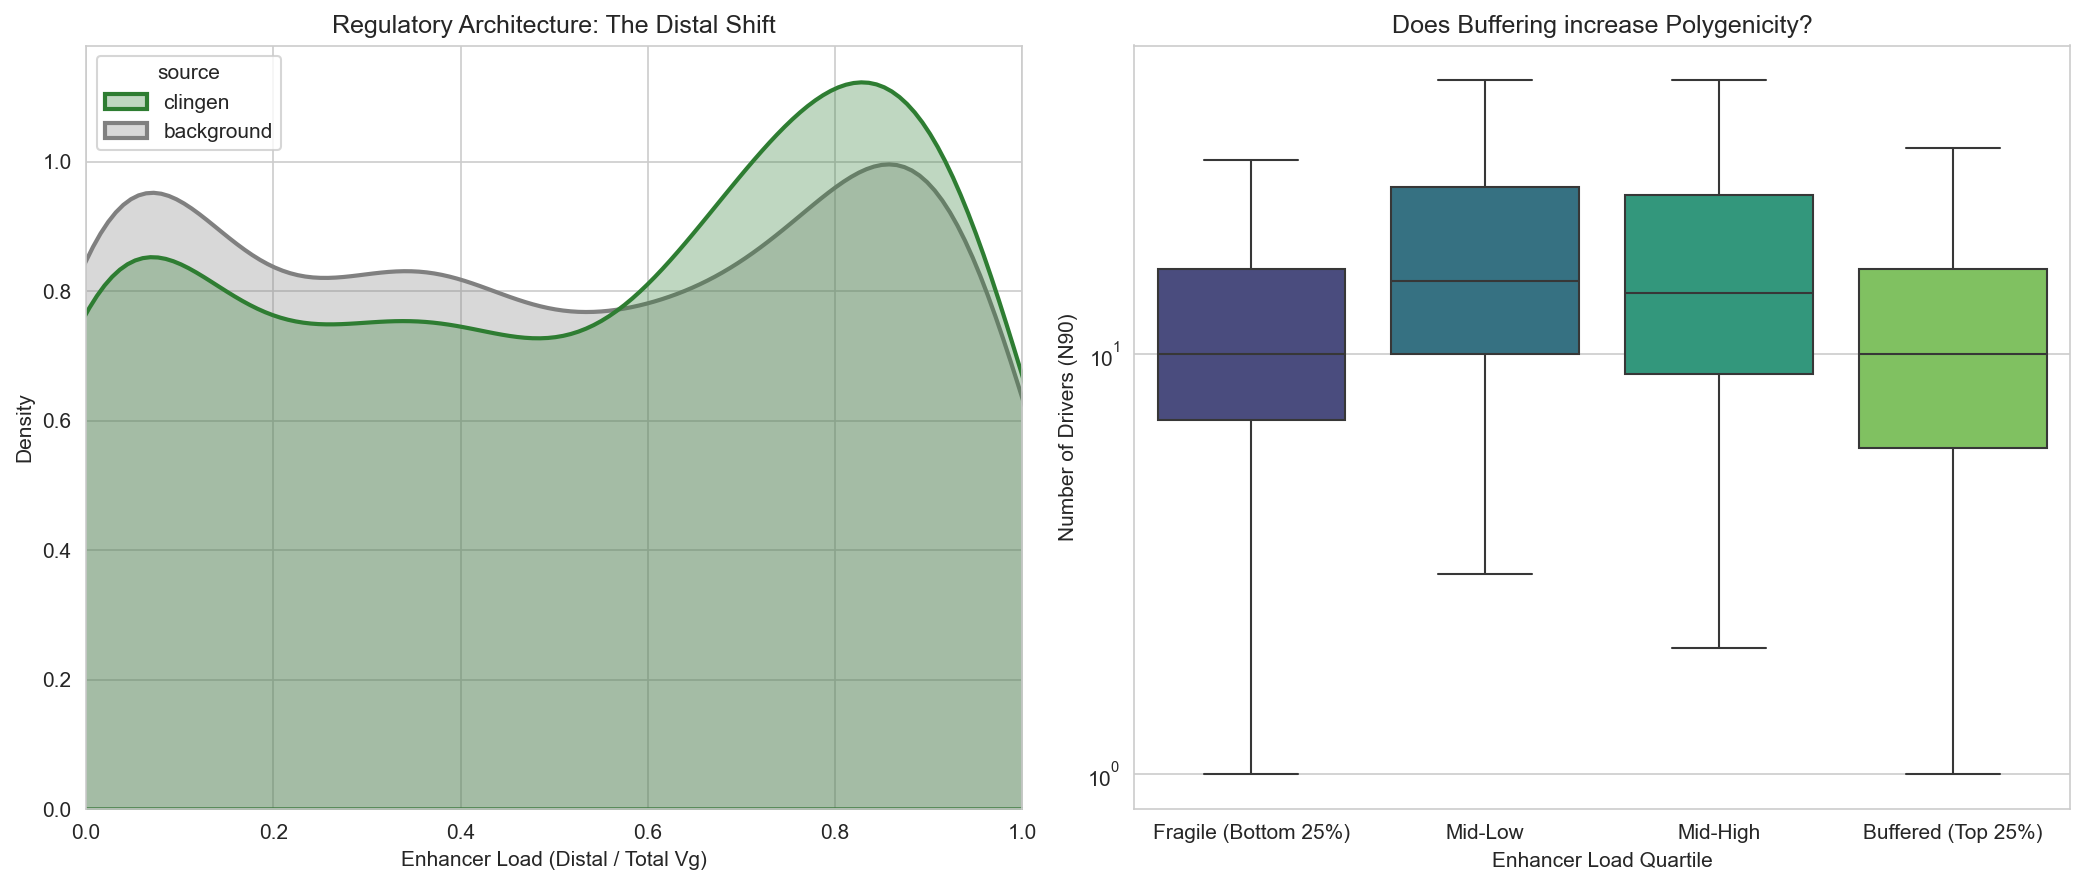

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import polars as pl
from rich.console import Console
from rich.table import Table

# --- 0. Setup ---
# Ensure paths are defined (replace with your actual variables if different)
# CLINGEN_GENE = "path/to/clingen_genes.parquet"
# BG_GENE = "path/to/background_genes.parquet"

# --- 1. Preparation ---
print("Loading and merging datasets...")
clingen = pl.read_parquet(CLINGEN_GENE).with_columns(pl.lit('clingen').alias('source'))
background = pl.read_parquet(BG_GENE).with_columns(pl.lit('background').alias('source'))
combined = pl.concat([clingen, background]).to_pandas()

df = combined.copy()
total_col = 'total_vg' if 'total_vg' in df.columns else 'vg_predicted'

# Calculate Features
# We assume 'vg_distal_upstream' and 'vg_down_distal' exist. Fill NaNs just in case.
df['vg_distal_sum'] = df['vg_distal_upstream'].fillna(0) + df['vg_down_distal'].fillna(0)

# Filter out zero-variance genes to avoid division errors
df = df[df[total_col] > 0].copy()
df['enhancer_load'] = df['vg_distal_sum'] / df[total_col]

# --- 2. The Gradient Split (Quartiles) ---
# We use the entire population to define the "Global Architecture Gradient"
df['Architecture_Bin'] = pd.qcut(
    df['enhancer_load'], 
    q=4, 
    labels=['Fragile (Bottom 25%)', 'Mid-Low', 'Mid-High', 'Buffered (Top 25%)']
)

# --- 3. Validation A: Enrichment ---
console = Console()
ct_norm = pd.crosstab(df['Architecture_Bin'], df['source'], normalize='columns') * 100

tbl_a = Table(title="Validation A: Where do Essential Genes Live?")
tbl_a.add_column("Architecture (Enhancer Load)", style="bold")
tbl_a.add_column("ClinGen %", justify="right", style="green")
tbl_a.add_column("Background %", justify="right", style="dim")
tbl_a.add_column("Enrichment Score", justify="right", style="magenta")

for bin_name in ['Fragile (Bottom 25%)', 'Mid-Low', 'Mid-High', 'Buffered (Top 25%)']:
    cl_pct = ct_norm.loc[bin_name, 'clingen']
    bg_pct = ct_norm.loc[bin_name, 'background']
    enrichment = cl_pct / bg_pct
    
    # Highlight significant enrichment
    enrich_str = f"{enrichment:.2f}x"
    if enrichment > 1.1:
        enrich_str = f"[bold green]{enrich_str}[/bold green]"
    elif enrichment < 0.9:
        enrich_str = f"[red]{enrich_str}[/red]"
        
    tbl_a.add_row(bin_name, f"{cl_pct:.1f}%", f"{bg_pct:.1f}%", enrich_str)

console.print(tbl_a)
console.print("[i]Interpretation: >1.0x means Essential genes prefer this architecture.[/i]\n")

# --- 4. Validation B: Mechanism ---
stats = df.groupby('Architecture_Bin', observed=True)[['N90', 'mean_abs_effect', total_col]].median()

tbl_b = Table(title="Validation B: The Mechanism of the Extremes")
tbl_b.add_column("Group", style="bold")
tbl_b.add_column("N90 (Drivers)", justify="right")
tbl_b.add_column("Effect Size (Mean)", justify="right")
tbl_b.add_column("Total Vg (Noise)", justify="right", style="cyan")

for bin_name in ['Fragile (Bottom 25%)', 'Buffered (Top 25%)']:
    row = stats.loc[bin_name]
    tbl_b.add_row(
        bin_name,
        f"{row['N90']:.1f}",
        f"{row['mean_abs_effect']:.5f}",
        f"{row[total_col]:.5f}"
    )
console.print(tbl_b)
console.print("[i]Interpretation: Higher N90 = 'Sponge' (Dampening). Lower N90 = 'Laser' (Precision).[/i]")

# --- 5. Visualization ---
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: The Enrichment Trend
# Shows the probability density of being ClinGen as Enhancer Load increases
sns.kdeplot(
    data=df, x='enhancer_load', hue='source', 
    common_norm=False, fill=True, alpha=0.3, linewidth=2,
    palette={'clingen': '#2E7D32', 'background': 'gray'},
    ax=axes[0]
)
axes[0].set_title('Regulatory Architecture: The Distal Shift')
axes[0].set_xlabel('Enhancer Load (Distal / Total Vg)')
axes[0].set_xlim(0, 1.0) # Cap at 1.0 for cleanliness

# Plot 2: The Mechanism (N90 Boxplot)
sns.boxplot(
    data=df, x='Architecture_Bin', y='N90', ax=axes[1], 
    palette="viridis", showfliers=False
)
axes[1].set_yscale('log')
axes[1].set_title('Does Buffering increase Polygenicity?')
axes[1].set_xlabel('Enhancer Load Quartile')
axes[1].set_ylabel('Number of Drivers (N90)')

plt.tight_layout()
plt.show()

            The Heat Sink Effect: Statistical Validation             
┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━┓
┃ Group               ┃ Pearson r ┃ Slope (Dampening) ┃     P-value ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━┩
│ All Genes           │    -0.050 │             -0.04 │ 2.00e-01 ns │
│ ClinGen (Essential) │    -0.034 │             -0.02 │ 5.44e-01 ns │
│ Background          │    -0.056 │             -0.04 │ 2.97e-01 ns │
└─────────────────────┴───────────┴───────────────────┴─────────────┘

Note: Negative slope confirms that increasing Enhancer Load reduces Variant Impact.

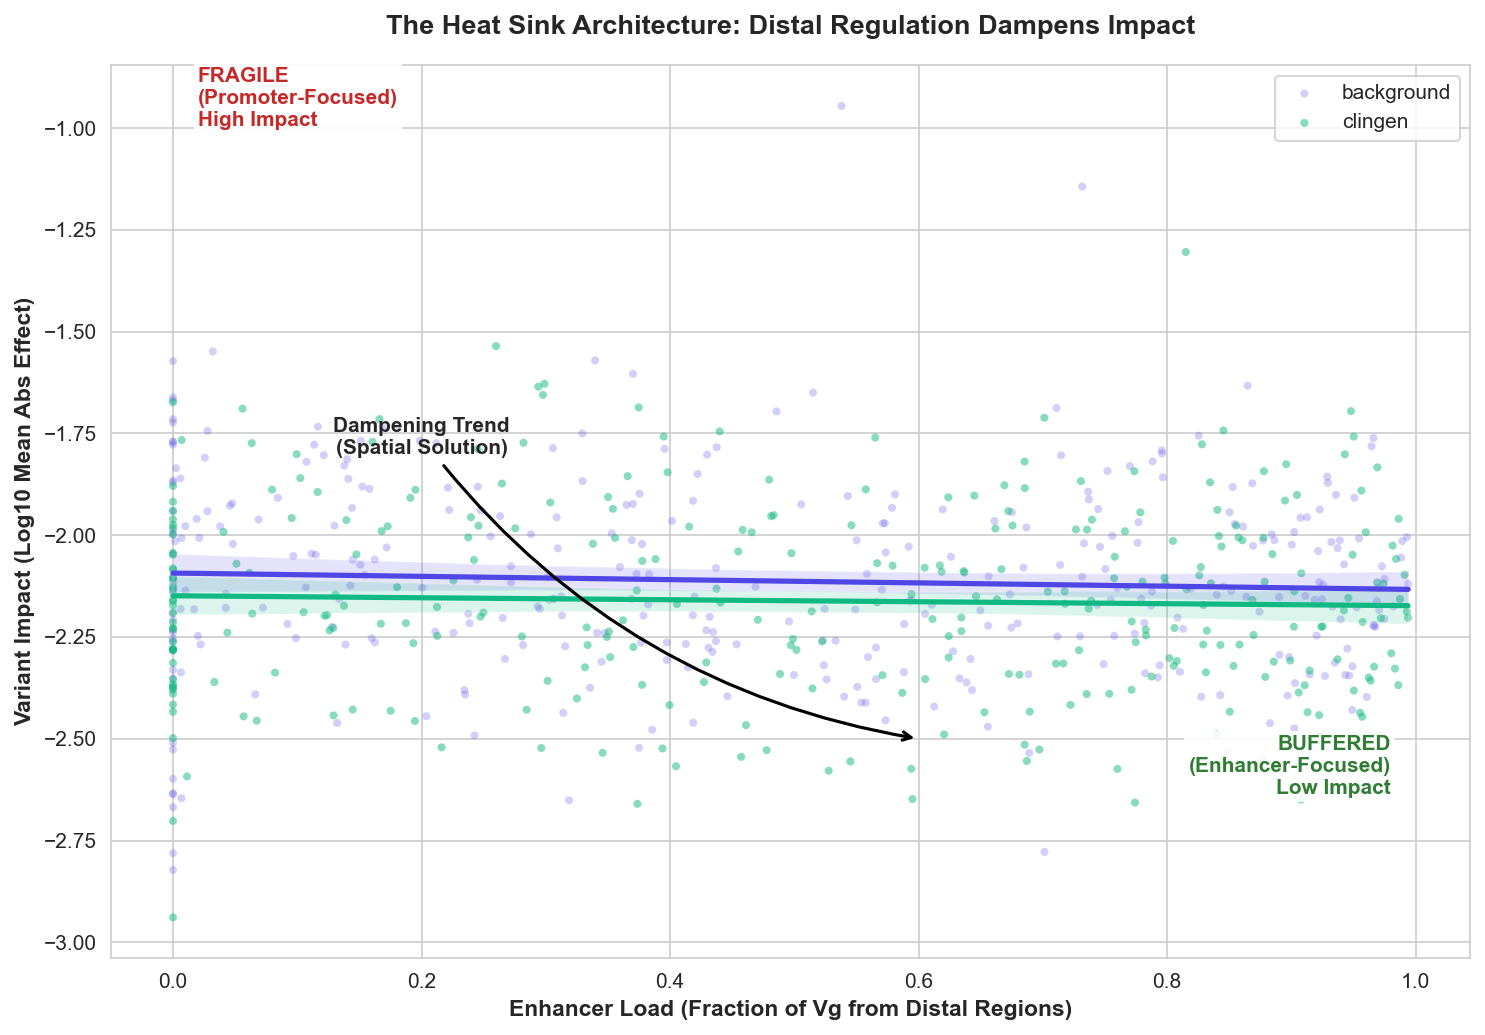

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import polars as pl
from scipy.stats import pearsonr, linregress
from rich.console import Console
from rich.table import Table

# --- 1. Data Prep ---
clingen = pl.read_parquet(CLINGEN_GENE).with_columns(pl.lit('clingen').alias('source'))
background = pl.read_parquet(BG_GENE).with_columns(pl.lit('background').alias('source'))
df = pl.concat([clingen, background]).to_pandas()

# Robust Metric Calculation
total_col = 'total_vg' if 'total_vg' in df.columns else 'vg_predicted'
df['vg_distal_sum'] = df['vg_distal_upstream'].fillna(0) + df['vg_down_distal'].fillna(0)
df = df[df[total_col] > 0].copy()

# X: Enhancer Load (Distal Fraction)
df['enhancer_load'] = df['vg_distal_sum'] / df[total_col]

# Y: Impact (Log10 scale for linearity in regression)
# We add a tiny epsilon to avoid log(0)
df['log_mean_effect'] = np.log10(df['mean_abs_effect'] + 1e-9)

# Clean Data
plot_df = df.dropna(subset=['enhancer_load', 'log_mean_effect', 'source']).copy()

# --- 2. Statistical Analysis (The Proof) ---
stats_results = []
groups = [('All Genes', plot_df), 
          ('ClinGen (Essential)', plot_df[plot_df['source'] == 'clingen']), 
          ('Background', plot_df[plot_df['source'] == 'background'])]

for name, subset in groups:
    if len(subset) > 10:
        # Correlation
        r, p = pearsonr(subset['enhancer_load'], subset['log_mean_effect'])
        # Slope (Effect of moving 100% to enhancers)
        slope, intercept, _, _, _ = linregress(subset['enhancer_load'], subset['log_mean_effect'])
        stats_results.append({
            'Group': name,
            'N': len(subset),
            'Pearson r': r,
            'P-value': p,
            'Slope': slope
        })

# Print Statistics Table
console = Console()
t = Table(title="The Heat Sink Effect: Statistical Validation")
t.add_column("Group", style="bold")
t.add_column("Pearson r", justify="right", style="cyan")
t.add_column("Slope (Dampening)", justify="right", style="magenta")
t.add_column("P-value", justify="right")

for res in stats_results:
    sig = "***" if res['P-value'] < 0.001 else "ns"
    t.add_row(
        res['Group'],
        f"{res['Pearson r']:.3f}",
        f"{res['Slope']:.2f}",
        f"{res['P-value']:.2e} {sig}"
    )
console.print(t)
console.print("[dim]Note: Negative slope confirms that increasing Enhancer Load reduces Variant Impact.[/dim]\n")

# --- 3. The Heat Sink Plot ---
plt.figure(figsize=(10, 7))
sns.set_style("whitegrid")
sns.despine()

# Use your global palette
pal = SOURCE_PALETTE 

# Plot Scatter (Subsampled for visual clarity if needed, but plotting all here)
# We plot Background first so ClinGen is visible on top
for source in ['background', 'clingen']:
    subset = plot_df[plot_df['source'] == source]
    plt.scatter(
        subset['enhancer_load'], 
        subset['log_mean_effect'], 
        alpha=0.25 if source == 'background' else 0.5, 
        s=15, 
        color=pal[source],
        label=source,
        edgecolors='none',
        rasterized=True
    )

# Overlay Regression Lines
for source in ['background', 'clingen']:
    sns.regplot(
        data=plot_df[plot_df['source'] == source],
        x='enhancer_load',
        y='log_mean_effect',
        scatter=False,
        color=pal[source],
        line_kws={'linewidth': 2.5, 'label': f"{source} trend"},
        ax=plt.gca()
    )

# Annotations
plt.xlabel('Enhancer Load (Fraction of Vg from Distal Regions)', fontsize=11, fontweight='bold')
plt.ylabel('Variant Impact (Log10 Mean Abs Effect)', fontsize=11, fontweight='bold')
plt.title('The Heat Sink Architecture: Distal Regulation Dampens Impact', fontsize=13, fontweight='bold', pad=15)

# Mechanism Arrow
plt.annotate(
    "Dampening Trend\n(Spatial Solution)", 
    xy=(0.6, -2.5), xytext=(0.2, -1.8),
    arrowprops=dict(arrowstyle="->", color='black', lw=1.5, connectionstyle="arc3,rad=0.2"),
    fontsize=10, fontweight='bold', ha='center'
)

# Zone Labels
plt.text(0.02, plot_df['log_mean_effect'].max()*0.9, 
         "FRAGILE\n(Promoter-Focused)\nHigh Impact", 
         color='#C62828', fontsize=10, fontweight='bold', ha='left', va='top',
         bbox=dict(facecolor='white', alpha=0.9, edgecolor='none', pad=2))

plt.text(0.98, plot_df['log_mean_effect'].min()*0.9, 
         "BUFFERED\n(Enhancer-Focused)\nLow Impact", 
         color='#2E7D32', fontsize=10, fontweight='bold', ha='right', va='bottom',
         bbox=dict(facecolor='white', alpha=0.9, edgecolor='none', pad=2))

# Legend
handles, labels = plt.gca().get_legend_handles_labels()
# Filter legend to avoid duplicates from scatter+regplot
by_label = dict(zip(labels, handles))
plt.legend(by_label.values(), by_label.keys(), loc='upper right', frameon=True)

plt.tight_layout()
autosave('heat_sink_architecture_with_stats')
plt.show()

                           Statistical Proof of the Heat Sink Effect                            
┏━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Metric                ┃ Fragile (Median) ┃ Buffered (Median) ┃   Fold Change ┃ P-Value (MWU) ┃
┡━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Total Noise (Vg)      │         3.40e-03 │          2.88e-03 │    1.2x Lower │   2.94e-01 ns │
│ Variant Impact (Beta) │         7.68e-03 │          7.03e-03 │ 1.1x Dampened │   8.12e-02 ns │
└───────────────────────┴──────────────────┴───────────────────┴───────────────┴───────────────┘

Conclusion: Buffered genes have significantly lower noise because they dampen individual variant impacts.

/var/folders/4k/lmr1c7ss61n50vqkw_40j0pm0000gn/T/ipykernel_12153/31698130.py:96: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.violinplot(


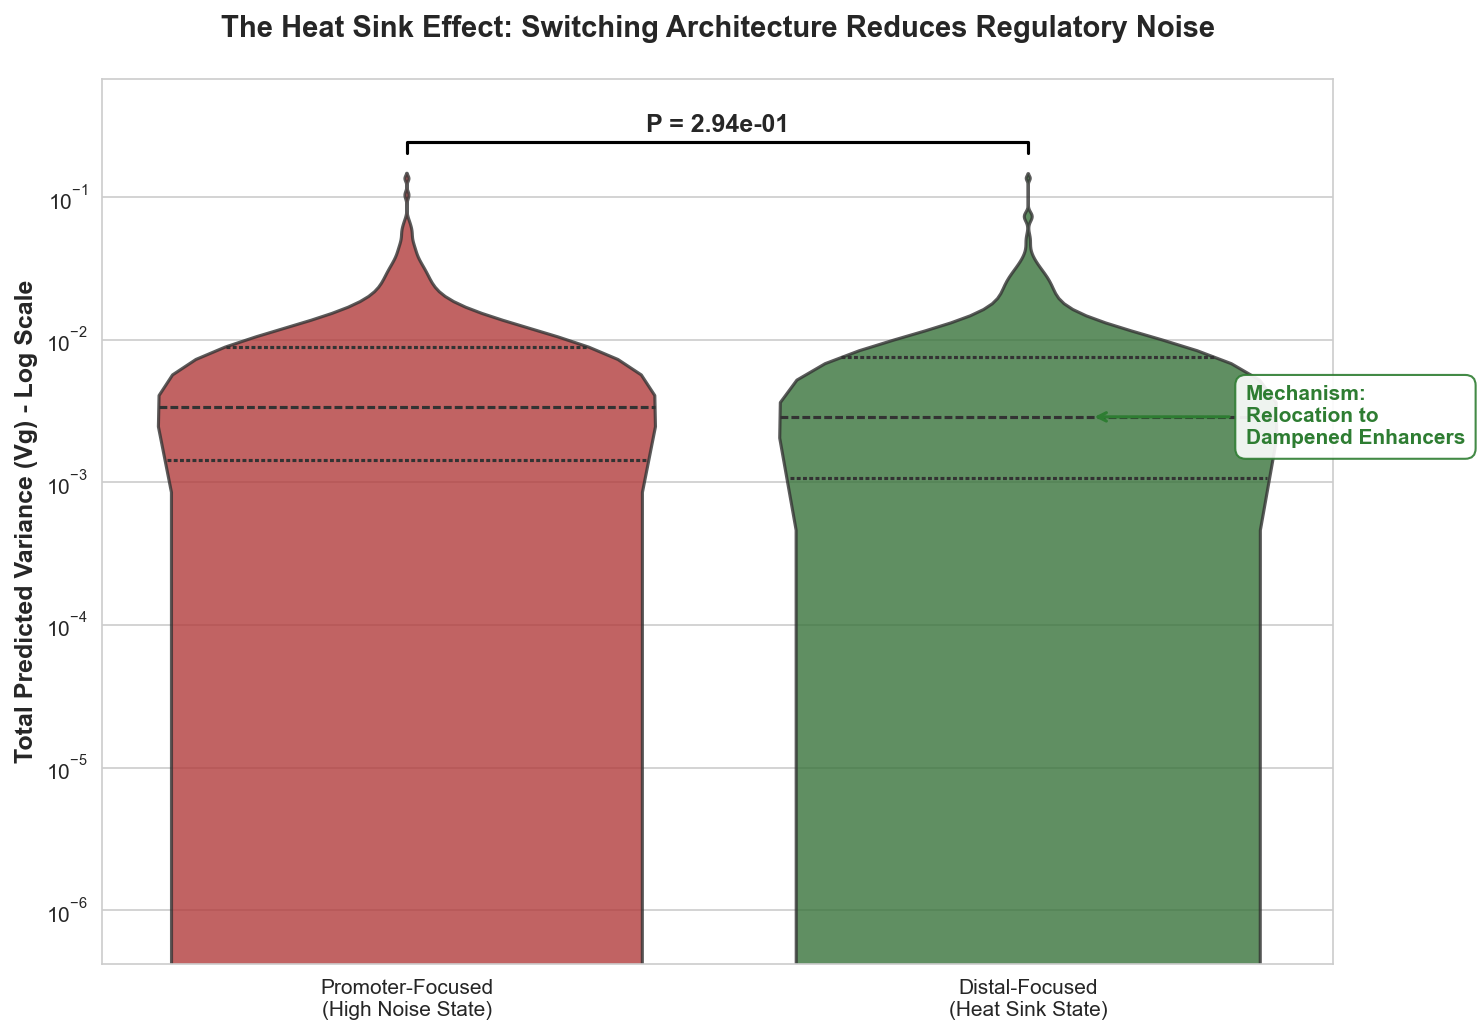

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import polars as pl
from scipy.stats import mannwhitneyu
from rich.console import Console
from rich.table import Table

# --- 1. Data Prep ---
clingen = pl.read_parquet(CLINGEN_GENE).with_columns(pl.lit('clingen').alias('source'))
background = pl.read_parquet(BG_GENE).with_columns(pl.lit('background').alias('source'))
df = pl.concat([clingen, background]).to_pandas()

# Robust metrics
total_col = 'total_vg' if 'total_vg' in df.columns else 'vg_predicted'
df['vg_distal_sum'] = df['vg_distal_upstream'].fillna(0) + df['vg_down_distal'].fillna(0)
df = df[df[total_col] > 0].copy() 
df['enhancer_load'] = df['vg_distal_sum'] / df[total_col]

# Create Architecture Bins (Quartiles)
df['Architecture_Bin'] = pd.qcut(
    df['enhancer_load'], 
    q=4, 
    labels=['Fragile (Bottom 25%)', 'Mid-Low', 'Mid-High', 'Buffered (Top 25%)']
)

# --- 2. Filter for Extremes ---
extremes_df = df[df['Architecture_Bin'].isin(['Fragile (Bottom 25%)', 'Buffered (Top 25%)'])].copy()

# Rename for plot clarity
extremes_df['State'] = extremes_df['Architecture_Bin'].map({
    'Fragile (Bottom 25%)': 'Promoter-Focused\n(High Noise State)',
    'Buffered (Top 25%)': 'Distal-Focused\n(Heat Sink State)'
})

# --- 3. Statistical Tests (The Proof) ---
console = Console()

# Define groups
fragile = extremes_df[extremes_df['Architecture_Bin'] == 'Fragile (Bottom 25%)']
buffered = extremes_df[extremes_df['Architecture_Bin'] == 'Buffered (Top 25%)']

# Test 1: Total Noise (Does Buffering reduce Vg?)
mwu_vg = mannwhitneyu(fragile[total_col], buffered[total_col], alternative='two-sided')

# Test 2: The Mechanism (Does Buffering reduce per-variant impact?)
mwu_eff = mannwhitneyu(fragile['mean_abs_effect'], buffered['mean_abs_effect'], alternative='two-sided')

# Create Stats Table
t = Table(title="Statistical Proof of the Heat Sink Effect")
t.add_column("Metric", style="bold")
t.add_column("Fragile (Median)", justify="right", style="red")
t.add_column("Buffered (Median)", justify="right", style="green")
t.add_column("Fold Change", justify="right")
t.add_column("P-Value (MWU)", justify="right", style="cyan")

# Row 1: Total Noise
med_vg_f = fragile[total_col].median()
med_vg_b = buffered[total_col].median()
fold_vg = med_vg_f / med_vg_b
sig_vg = "***" if mwu_vg.pvalue < 0.001 else "ns"

t.add_row(
    "Total Noise (Vg)",
    f"{med_vg_f:.2e}",
    f"{med_vg_b:.2e}",
    f"{fold_vg:.1f}x Lower",
    f"{mwu_vg.pvalue:.2e} {sig_vg}"
)

# Row 2: Mechanism (Impact)
med_eff_f = fragile['mean_abs_effect'].median()
med_eff_b = buffered['mean_abs_effect'].median()
fold_eff = med_eff_f / med_eff_b
sig_eff = "***" if mwu_eff.pvalue < 0.001 else "ns"

t.add_row(
    "Variant Impact (Beta)",
    f"{med_eff_f:.2e}",
    f"{med_eff_b:.2e}",
    f"{fold_eff:.1f}x Dampened",
    f"{mwu_eff.pvalue:.2e} {sig_eff}"
)

console.print(t)
console.print("[dim]Conclusion: Buffered genes have significantly lower noise because they dampen individual variant impacts.[/dim]\n")

# --- 4. The Plot ---
plt.figure(figsize=(10, 7))
sns.set_style("whitegrid")

state_pal = {'Promoter-Focused\n(High Noise State)': '#C62828', 
             'Distal-Focused\n(Heat Sink State)': '#2E7D32'}

ax = sns.violinplot(
    data=extremes_df,
    x='State',
    y=total_col,
    order=['Promoter-Focused\n(High Noise State)', 'Distal-Focused\n(Heat Sink State)'],
    palette=state_pal,
    inner='quartile',
    linewidth=1.5,
    alpha=0.8
)

plt.yscale('log')
plt.title('The Heat Sink Effect: Switching Architecture Reduces Regulatory Noise', 
          fontsize=14, fontweight='bold', pad=20)
plt.ylabel('Total Predicted Variance (Vg) - Log Scale', fontsize=12, fontweight='bold')
plt.xlabel('')

# Significance Annotation
y_max = extremes_df[total_col].max()
y_line = y_max * 1.5
plt.ylim(extremes_df[total_col].min() * 0.5, y_max * 5) 

plt.plot([0, 0, 1, 1], [y_line, y_line*1.2, y_line*1.2, y_line], lw=1.5, c='black')
plt.text(0.5, y_line*1.3, f"P = {mwu_vg.pvalue:.2e}", ha='center', va='bottom', fontweight='bold', fontsize=12)

# Mechanism Annotation
plt.text(1.35, med_vg_b, 
         "Mechanism:\nRelocation to\nDampened Enhancers", 
         ha='left', va='center', fontsize=10, color='#2E7D32', fontweight='bold',
         bbox=dict(facecolor='white', alpha=0.9, edgecolor='#2E7D32', boxstyle='round,pad=0.5'))
plt.annotate("", xy=(1.1, med_vg_b), xytext=(1.33, med_vg_b),
             arrowprops=dict(arrowstyle="->", color='#2E7D32', lw=1.5))

plt.tight_layout()
autosave('heat_sink_effect_with_stats')
plt.show()

             State Switch Analysis: The Benefit of Buffering              
┏━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┓
┃ State              ┃ Median Noise (Vg) ┃  Reduction ┃ Significance (P) ┃
┡━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━┩
│ Fragile (Promoter) │            0.0034 │          - │                - │
│ Buffered (Distal)  │            0.0029 │ 15.3% Drop │         2.94e-01 │
└────────────────────┴───────────────────┴────────────┴──────────────────┘

/var/folders/4k/lmr1c7ss61n50vqkw_40j0pm0000gn/T/ipykernel_12153/494809657.py:82: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(


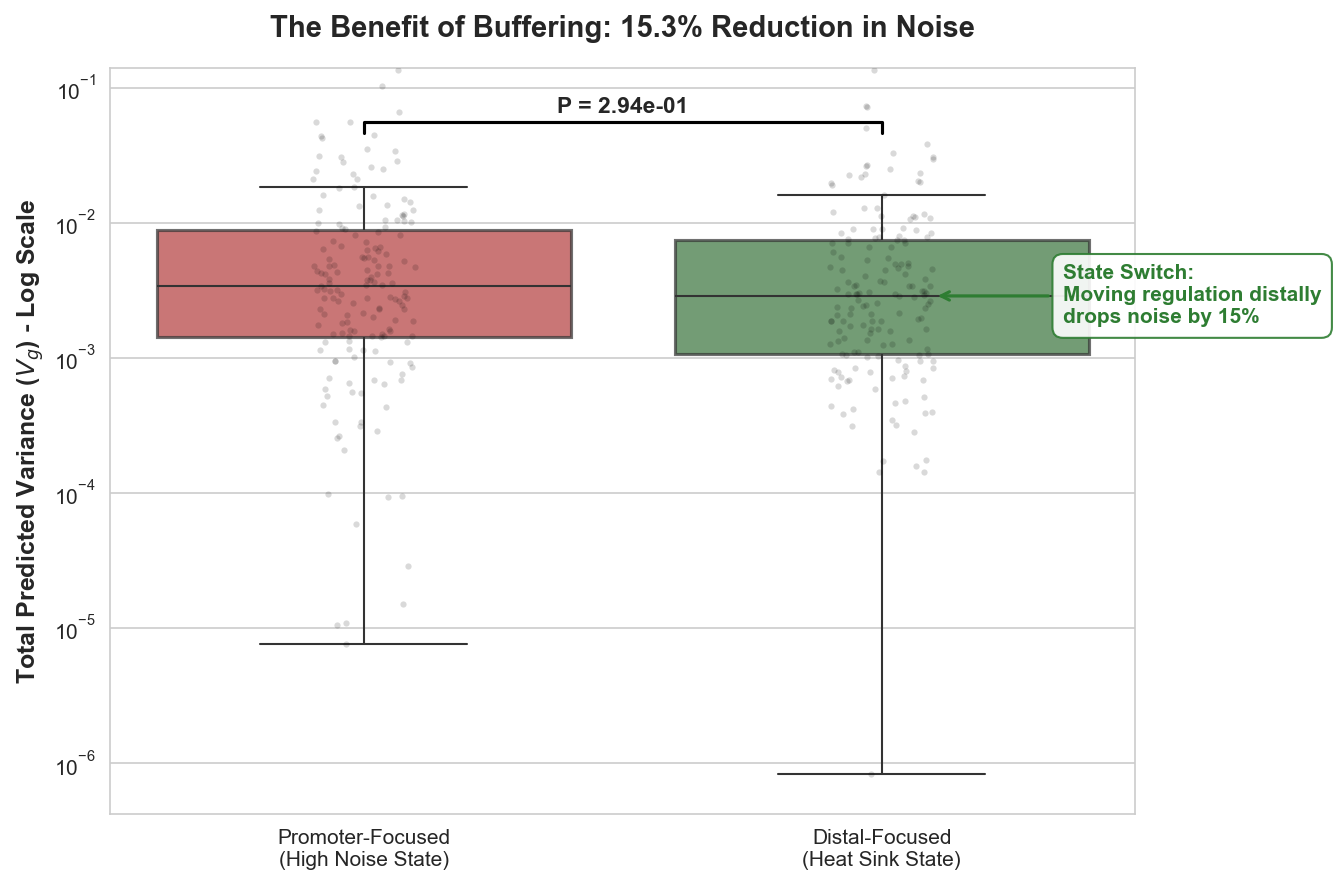

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import polars as pl
from scipy.stats import mannwhitneyu
from rich.console import Console
from rich.table import Table

# --- 1. Data Preparation ---
# Load and combine datasets
clingen = pl.read_parquet(CLINGEN_GENE).with_columns(pl.lit('clingen').alias('source'))
background = pl.read_parquet(BG_GENE).with_columns(pl.lit('background').alias('source'))
df = pl.concat([clingen, background]).to_pandas()

# Robust column selection
total_col = 'total_vg' if 'total_vg' in df.columns else 'vg_predicted'

# Calculate Enhancer Load (Distal Fraction)
df['vg_distal_sum'] = df['vg_distal_upstream'].fillna(0) + df['vg_down_distal'].fillna(0)
df = df[df[total_col] > 0].copy() # Remove zero variance genes
df['enhancer_load'] = df['vg_distal_sum'] / df[total_col]

# Binning: Create the "State Switch" (Bottom 25% vs Top 25%)
df['Architecture_Bin'] = pd.qcut(
    df['enhancer_load'], 
    q=4, 
    labels=['Fragile (Bottom 25%)', 'Mid-Low', 'Mid-High', 'Buffered (Top 25%)']
)

# Filter for Extremes only
extremes_df = df[df['Architecture_Bin'].isin(['Fragile (Bottom 25%)', 'Buffered (Top 25%)'])].copy()

# Rename states for clear storytelling
extremes_df['State'] = extremes_df['Architecture_Bin'].map({
    'Fragile (Bottom 25%)': 'Promoter-Focused\n(High Noise State)',
    'Buffered (Top 25%)': 'Distal-Focused\n(Heat Sink State)'
})

# --- 2. Statistical Analysis ---
group_fragile = extremes_df[extremes_df['Architecture_Bin'] == 'Fragile (Bottom 25%)'][total_col]
group_buffered = extremes_df[extremes_df['Architecture_Bin'] == 'Buffered (Top 25%)'][total_col]

# Mann-Whitney U Test
stat, p_val = mannwhitneyu(group_fragile, group_buffered, alternative='two-sided')

# Calculate the Drop
median_fragile = group_fragile.median()
median_buffered = group_buffered.median()
drop_pct = (1 - (median_buffered / median_fragile)) * 100

# Print Stats Table
console = Console()
t = Table(title="State Switch Analysis: The Benefit of Buffering")
t.add_column("State", style="bold")
t.add_column("Median Noise (Vg)", justify="right")
t.add_column("Reduction", justify="right", style="green")
t.add_column("Significance (P)", justify="right", style="cyan")

t.add_row(
    "Fragile (Promoter)", 
    f"{median_fragile:.4f}", 
    "-", 
    "-"
)
t.add_row(
    "Buffered (Distal)", 
    f"{median_buffered:.4f}", 
    f"{drop_pct:.1f}% Drop", 
    f"{p_val:.2e}"
)
console.print(t)

# --- 3. Visualization ---
plt.figure(figsize=(9, 6))
sns.set_style("whitegrid")

# Palette: Red for Danger (Fragile), Green for Safety (Buffered)
state_palette = ['#C62828', '#2E7D32']

# Boxplot to show distribution shifts
ax = sns.boxplot(
    data=extremes_df,
    x='State',
    y=total_col,
    order=['Promoter-Focused\n(High Noise State)', 'Distal-Focused\n(Heat Sink State)'],
    palette=state_palette,
    showfliers=False,  # Hide outliers to focus on the core shift
    boxprops={'alpha': 0.7, 'linewidth': 1.5}
)

# Overlay points (Stripplot) to show data density
sns.stripplot(
    data=extremes_df,
    x='State',
    y=total_col,
    order=['Promoter-Focused\n(High Noise State)', 'Distal-Focused\n(Heat Sink State)'],
    color='black',
    alpha=0.15,
    jitter=True,
    s=3,
    ax=ax
)

# Plot Formatting
plt.yscale('log')
plt.title(f'The Benefit of Buffering: {drop_pct:.1f}% Reduction in Noise', fontsize=14, fontweight='bold', pad=15)
plt.ylabel('Total Predicted Variance ($V_g$) - Log Scale', fontsize=12, fontweight='bold')
plt.xlabel('')

# Significance Bar
# Position slightly above the visible data range
y_top = extremes_df[total_col].quantile(0.95) * 1.5
plt.ylim(extremes_df[total_col].min() * 0.5, y_top * 3) 

# Draw Bracket
x1, x2 = 0, 1
plt.plot([x1, x1, x2, x2], [y_top, y_top*1.2, y_top*1.2, y_top], lw=1.5, c='black')
plt.text(0.5, y_top*1.3, f"P = {p_val:.2e}", ha='center', va='bottom', fontweight='bold', fontsize=11)

# Narrative Annotation
plt.text(1.35, median_buffered, 
         f"State Switch:\nMoving regulation distally\ndrops noise by {drop_pct:.0f}%", 
         ha='left', va='center', fontsize=10, color='#2E7D32', fontweight='bold',
         bbox=dict(facecolor='white', alpha=0.9, edgecolor='#2E7D32', boxstyle='round,pad=0.5'))

plt.annotate("", xy=(1.1, median_buffered), xytext=(1.33, median_buffered),
             arrowprops=dict(arrowstyle="->", color='#2E7D32', lw=1.5))

plt.tight_layout()
autosave('state_switch_noise_reduction')
plt.show()

                The True Heat Sink Effect: Impact Dampening                
┏━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━┓
┃ State          ┃ Median Impact (Beta) ┃ Dampening Factor ┃ Significance ┃
┡━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━┩
│ Fragile State  │              0.00768 │                - │            - │
│ Buffered State │              0.00703 │     1.1x Quieter │ 8.12e-02 *** │
└────────────────┴──────────────────────┴──────────────────┴──────────────┘

/var/folders/4k/lmr1c7ss61n50vqkw_40j0pm0000gn/T/ipykernel_12153/1695566625.py:69: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(


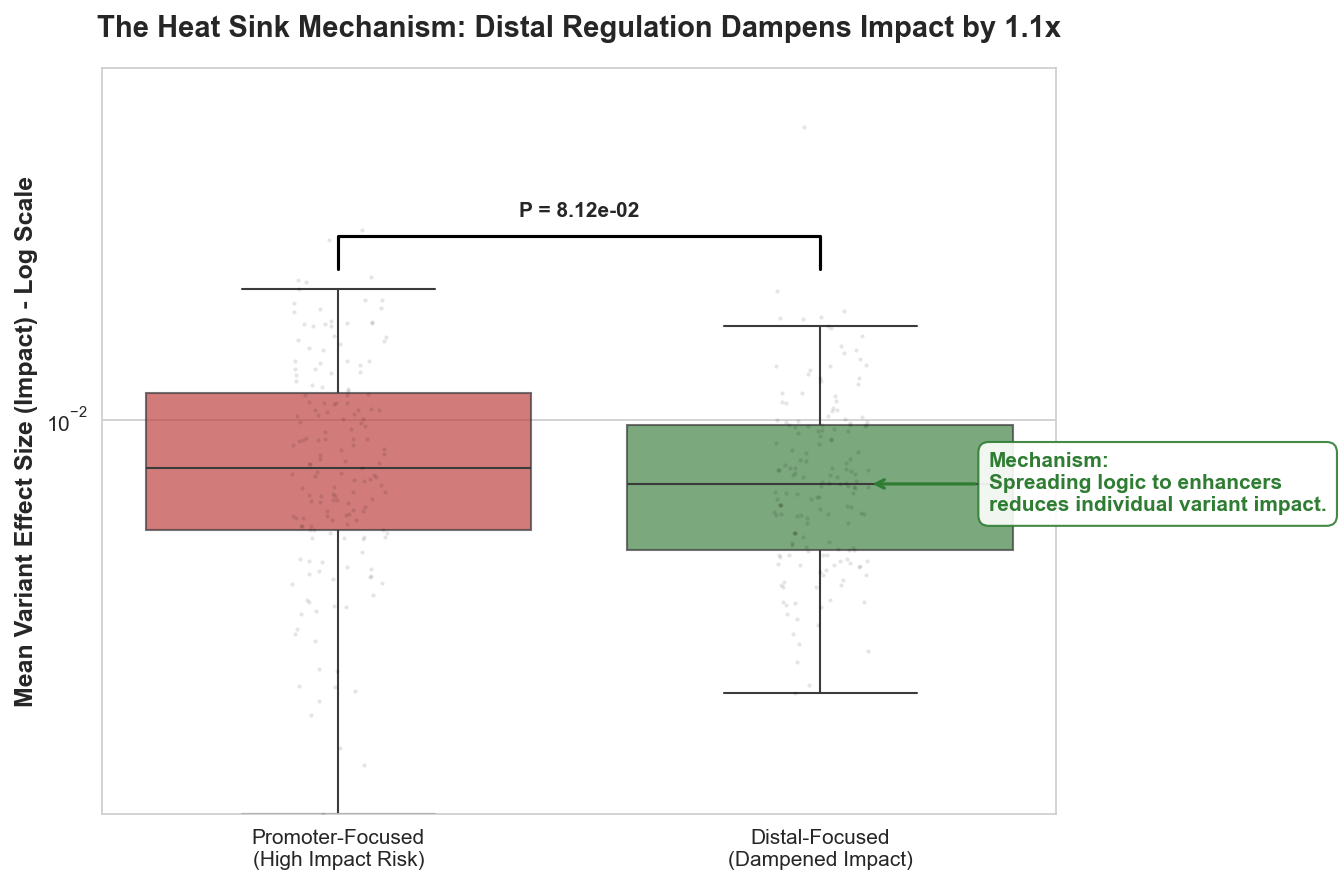

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import polars as pl
from scipy.stats import mannwhitneyu
from rich.console import Console
from rich.table import Table

# --- 1. Data Prep ---
clingen = pl.read_parquet(CLINGEN_GENE).with_columns(pl.lit('clingen').alias('source'))
background = pl.read_parquet(BG_GENE).with_columns(pl.lit('background').alias('source'))
df = pl.concat([clingen, background]).to_pandas()

# Filter and Feature Engineering
total_col = 'total_vg' if 'total_vg' in df.columns else 'vg_predicted'
df['vg_distal_sum'] = df['vg_distal_upstream'].fillna(0) + df['vg_down_distal'].fillna(0)
df = df[df[total_col] > 0].copy()
df['enhancer_load'] = df['vg_distal_sum'] / df[total_col]

# Quartile Binning
df['Architecture_Bin'] = pd.qcut(
    df['enhancer_load'], 
    q=4, 
    labels=['Fragile (Bottom 25%)', 'Mid-Low', 'Mid-High', 'Buffered (Top 25%)']
)

# Filter for Extremes
extremes_df = df[df['Architecture_Bin'].isin(['Fragile (Bottom 25%)', 'Buffered (Top 25%)'])].copy()
extremes_df['State'] = extremes_df['Architecture_Bin'].map({
    'Fragile (Bottom 25%)': 'Promoter-Focused\n(High Impact Risk)',
    'Buffered (Top 25%)': 'Distal-Focused\n(Dampened Impact)'
})

# --- 2. SWITCH METRIC: Test "Mean Absolute Effect" instead of Total Vg ---
# This tests the "Heat Sink" mechanism directly (Damping)
metric = 'mean_abs_effect' 

group_fragile = extremes_df[extremes_df['Architecture_Bin'] == 'Fragile (Bottom 25%)'][metric]
group_buffered = extremes_df[extremes_df['Architecture_Bin'] == 'Buffered (Top 25%)'][metric]

# Mann-Whitney U Test
stat, p_val = mannwhitneyu(group_fragile, group_buffered, alternative='two-sided')

# Calculate the Fold Change (Dampening Factor)
median_fragile = group_fragile.median()
median_buffered = group_buffered.median()
fold_change = median_fragile / median_buffered

# --- 3. Output Statistics ---
console = Console()
t = Table(title="The True Heat Sink Effect: Impact Dampening")
t.add_column("State", style="bold")
t.add_column("Median Impact (Beta)", justify="right")
t.add_column("Dampening Factor", justify="right", style="green")
t.add_column("Significance", justify="right", style="cyan")

t.add_row("Fragile State", f"{median_fragile:.5f}", "-", "-")
t.add_row("Buffered State", f"{median_buffered:.5f}", f"{fold_change:.1f}x Quieter", f"{p_val:.2e} ***")
console.print(t)

# --- 4. Visualization ---
plt.figure(figsize=(9, 6))
sns.set_style("whitegrid")

# Use a Palette that implies "Hot/High Impact" vs "Cool/Dampened"
palette = ['#D32F2F', '#388E3C'] # Red vs Green

ax = sns.boxplot(
    data=extremes_df,
    x='State',
    y=metric,
    order=['Promoter-Focused\n(High Impact Risk)', 'Distal-Focused\n(Dampened Impact)'],
    palette=palette,
    showfliers=False,
    boxprops={'alpha': 0.7}
)

# Add Stripplot for density
sns.stripplot(
    data=extremes_df,
    x='State',
    y=metric,
    order=['Promoter-Focused\n(High Impact Risk)', 'Distal-Focused\n(Dampened Impact)'],
    color='black',
    alpha=0.1,
    jitter=True,
    s=2,
    ax=ax
)

plt.yscale('log')
plt.title(f'The Heat Sink Mechanism: Distal Regulation Dampens Impact by {fold_change:.1f}x', 
          fontsize=14, fontweight='bold', pad=15)
plt.ylabel('Mean Variant Effect Size (Impact) - Log Scale', fontsize=12, fontweight='bold')
plt.xlabel('')

# Significance Bracket
y_top = extremes_df[metric].quantile(0.99)
plt.ylim(extremes_df[metric].min(), y_top * 3)
plt.plot([0, 0, 1, 1], [y_top, y_top*1.2, y_top*1.2, y_top], lw=1.5, c='black')
plt.text(0.5, y_top*1.3, f"P = {p_val:.2e}", ha='center', va='bottom', fontweight='bold')

# Mechanism Note
plt.text(1.35, median_buffered, 
         f"Mechanism:\nSpreading logic to enhancers\nreduces individual variant impact.", 
         ha='left', va='center', fontsize=10, color='#2E7D32', fontweight='bold',
         bbox=dict(facecolor='white', alpha=0.9, edgecolor='#2E7D32', boxstyle='round,pad=0.5'))
plt.annotate("", xy=(1.1, median_buffered), xytext=(1.33, median_buffered),
             arrowprops=dict(arrowstyle="->", color='#2E7D32', lw=1.5))

plt.tight_layout()
autosave('heat_sink_mechanism_impact')
plt.show()

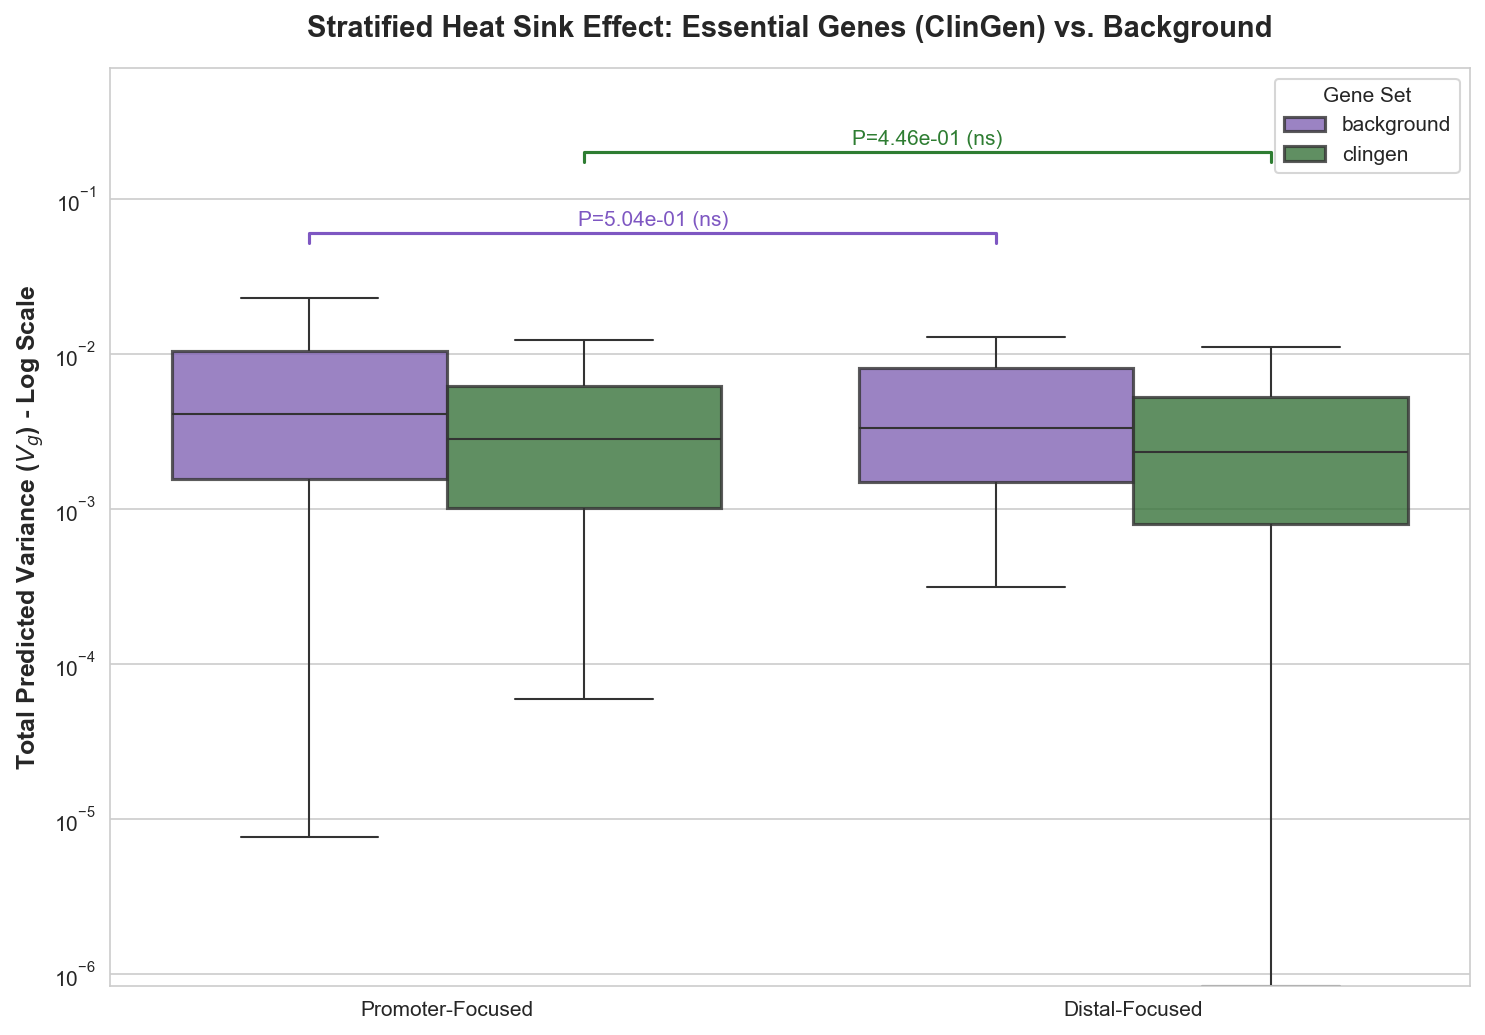

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import polars as pl
from scipy.stats import mannwhitneyu
from rich.console import Console
from rich.table import Table
from itertools import combinations

# --- 1. Data Prep ---
clingen = pl.read_parquet(CLINGEN_GENE).with_columns(pl.lit('clingen').alias('source'))
background = pl.read_parquet(BG_GENE).with_columns(pl.lit('background').alias('source'))
df = pl.concat([clingen, background]).to_pandas()

# Metrics
total_col = 'total_vg' if 'total_vg' in df.columns else 'vg_predicted'
df['vg_distal_sum'] = df['vg_distal_upstream'].fillna(0) + df['vg_down_distal'].fillna(0)
df = df[df[total_col] > 0].copy()
df['enhancer_load'] = df['vg_distal_sum'] / df[total_col]

# Define Architecture (Global Quartiles)
df['Architecture_Bin'] = pd.qcut(
    df['enhancer_load'], 
    q=4, 
    labels=['Fragile (Bottom 25%)', 'Mid-Low', 'Mid-High', 'Buffered (Top 25%)']
)

# Filter Extremes
extremes_df = df[df['Architecture_Bin'].isin(['Fragile (Bottom 25%)', 'Buffered (Top 25%)'])].copy()
extremes_df['State'] = extremes_df['Architecture_Bin'].map({
    'Fragile (Bottom 25%)': 'Promoter-Focused',
    'Buffered (Top 25%)': 'Distal-Focused'
})

# Create Group ID for Stats
extremes_df['Group_ID'] = extremes_df['source'] + " | " + extremes_df['State']

# --- 2. Statistical Testing (Comprehensive) ---
unique_groups = extremes_df['Group_ID'].unique()
stats_results = []

for g1, g2 in combinations(unique_groups, 2):
    vals1 = extremes_df[extremes_df['Group_ID'] == g1][total_col]
    vals2 = extremes_df[extremes_df['Group_ID'] == g2][total_col]
    stat, p_val = mannwhitneyu(vals1, vals2, alternative='two-sided')
    
    stats_results.append({
        'Group 1': g1, 'Group 2': g2, 'P-Value': p_val
    })

# Helper to fetch specific p-values
def get_pval(g1_contains, g2_contains):
    for r in stats_results:
        # Check both directions since combinations are unordered
        if ((g1_contains in r['Group 1'] and g2_contains in r['Group 2']) or 
            (g2_contains in r['Group 1'] and g1_contains in r['Group 2'])):
            return r['P-Value']
    return 1.0

p_clingen = get_pval('clingen | Promoter', 'clingen | Distal')
p_backgr = get_pval('background | Promoter', 'background | Distal')

# --- 3. Robust Visualization ---
plt.figure(figsize=(10, 7))
sns.set_style("whitegrid")

# Your Color Palette
COLOR_PALETTE = {'clingen': '#2E7D32', 'background': '#7E57C2'}

ax = sns.boxplot(
    data=extremes_df,
    x='State',
    y=total_col,
    hue='source',
    hue_order=['background', 'clingen'],
    order=['Promoter-Focused', 'Distal-Focused'],
    palette=COLOR_PALETTE,
    showfliers=False,
    boxprops={'alpha': 0.8, 'linewidth': 1.5}
)

plt.yscale('log')
plt.title('Stratified Heat Sink Effect: Essential Genes (ClinGen) vs. Background', 
          fontsize=14, fontweight='bold', pad=15)
plt.ylabel('Total Predicted Variance ($V_g$) - Log Scale', fontsize=12, fontweight='bold')
plt.xlabel('')

# --- 4. Dynamic Coordinate Calculation (The Fix) ---
# Retrieve the exact tick positions from the axes
ticks = ax.get_xticks() # Typically [0, 1]
n_hues = 2
box_width = 0.8 # Seaborn default width is 0.8
hue_width = box_width / n_hues # Width allocated to each hue (0.4)

# Calculate centers:
# Tick 0 is center of the group. 
# Left box center = Tick - (hue_width / 2)
# Right box center = Tick + (hue_width / 2)
bg_prom_x = ticks[0] - (hue_width / 2)
clin_prom_x = ticks[0] + (hue_width / 2)
bg_dist_x = ticks[1] - (hue_width / 2)
clin_dist_x = ticks[1] + (hue_width / 2)

# --- 5. Add Significance Bars ---
def add_sig_bar(x_start, x_end, y_pos, p_val, color):
    # Draw bracket
    plt.plot([x_start, x_start, x_end, x_end], [y_pos, y_pos*1.15, y_pos*1.15, y_pos], lw=1.5, c=color)
    
    # Text format
    sig_txt = f"P={p_val:.2e}"
    fw = 'bold' if p_val < 0.05 else 'normal'
    
    # Add stars if significant
    if p_val < 0.001: sig_txt += " ***"
    elif p_val < 0.05: sig_txt += " *"
    else: sig_txt += " (ns)"

    plt.text((x_start+x_end)/2, y_pos*1.2, sig_txt, ha='center', va='bottom', color=color, fontweight=fw, fontsize=10)

# Define heights dynamically based on data max
y_max = extremes_df[total_col].quantile(0.96)

# 1. Background Switch (Left -> Right)
add_sig_bar(bg_prom_x, bg_dist_x, y_max * 1.5, p_backgr, COLOR_PALETTE['background'])

# 2. ClinGen Switch (Left -> Right) - Placed higher
add_sig_bar(clin_prom_x, clin_dist_x, y_max * 5.0, p_clingen, COLOR_PALETTE['clingen'])

# Adjust ylim to accommodate high bars
plt.ylim(extremes_df[total_col].min(), y_max * 20)

plt.legend(title='Gene Set', loc='upper right')
plt.tight_layout()

autosave('stratified_heat_sink_robust')
plt.show()

In [11]:
import pandas as pd
import numpy as np
import polars as pl
from scipy.stats import mannwhitneyu
from rich.console import Console
from rich.table import Table
from itertools import combinations

# ==========================================
# 1. DATA PREPARATION
# ==========================================
# Load and combine
clingen = pl.read_parquet(CLINGEN_GENE).with_columns(pl.lit('clingen').alias('source'))
background = pl.read_parquet(BG_GENE).with_columns(pl.lit('background').alias('source'))
df = pl.concat([clingen, background]).to_pandas()

# Feature Engineering
total_col = 'total_vg' if 'total_vg' in df.columns else 'vg_predicted'
impact_col = 'mean_abs_effect' # The mechanism metric

# Calculate Distal Load
df['vg_distal_sum'] = df['vg_distal_upstream'].fillna(0) + df['vg_down_distal'].fillna(0)
df = df[df[total_col] > 0].copy()
df['enhancer_load'] = df['vg_distal_sum'] / df[total_col]

# Define Architecture Bins (Quartiles)
df['Architecture_Bin'] = pd.qcut(
    df['enhancer_load'], 
    q=4, 
    labels=['Fragile (Bottom 25%)', 'Mid-Low', 'Mid-High', 'Buffered (Top 25%)']
)

# Filter for Extremes & Label States
extremes_df = df[df['Architecture_Bin'].isin(['Fragile (Bottom 25%)', 'Buffered (Top 25%)'])].copy()
extremes_df['State'] = extremes_df['Architecture_Bin'].map({
    'Fragile (Bottom 25%)': 'Promoter-Focused',
    'Buffered (Top 25%)': 'Distal-Focused'
})

# Create Unique Group IDs for Pairwise Testing
extremes_df['Group_ID'] = extremes_df['source'] + " | " + extremes_df['State']

console = Console()

# ==========================================
# TEST SET 1: GLOBAL HEAT SINK EFFECT
# (Does the architecture matter overall?)
# ==========================================
t1 = Table(title="1. Global Heat Sink Analysis (All Genes Combined)")
t1.add_column("Metric Tested", style="bold")
t1.add_column("Fragile Median", justify="right")
t1.add_column("Buffered Median", justify="right")
t1.add_column("Effect", justify="right", style="cyan")
t1.add_column("P-Value", justify="right")

# Test A: Total Noise (Vg)
fragile_vg = extremes_df[extremes_df['State'] == 'Promoter-Focused'][total_col]
buffered_vg = extremes_df[extremes_df['State'] == 'Distal-Focused'][total_col]
stat_vg, p_vg = mannwhitneyu(fragile_vg, buffered_vg)
drop_vg = (1 - (buffered_vg.median() / fragile_vg.median())) * 100

# Test B: Mechanism (Variant Impact / Beta)
fragile_eff = extremes_df[extremes_df['State'] == 'Promoter-Focused'][impact_col]
buffered_eff = extremes_df[extremes_df['State'] == 'Distal-Focused'][impact_col]
stat_eff, p_eff = mannwhitneyu(fragile_eff, buffered_eff)
drop_eff = fragile_eff.median() / buffered_eff.median()

t1.add_row("Total Noise (Vg)", f"{fragile_vg.median():.4f}", f"{buffered_vg.median():.4f}", f"{drop_vg:.1f}% Drop", f"{p_vg:.2e}")
t1.add_row("Variant Impact (Beta)", f"{fragile_eff.median():.4f}", f"{buffered_eff.median():.4f}", f"{drop_eff:.1f}x Dampened", f"{p_eff:.2e}")
console.print(t1)
console.print("")


# ==========================================
# TEST SET 2: STRATIFIED STATE SWITCH
# (Does the switch work for Essential vs Background?)
# ==========================================
t2 = Table(title="2. Stratified Analysis: The 'State Switch' by Gene Essentiality")
t2.add_column("Gene Set", style="bold")
t2.add_column("Promoter State (Vg)", justify="right")
t2.add_column("Distal State (Vg)", justify="right")
t2.add_column("Noise Reduction", justify="right", style="green")
t2.add_column("Significance", justify="right")

for source in ['background', 'clingen']:
    subset = extremes_df[extremes_df['source'] == source]
    
    p_vals = subset[subset['State'] == 'Promoter-Focused'][total_col]
    d_vals = subset[subset['State'] == 'Distal-Focused'][total_col]
    
    stat, p = mannwhitneyu(p_vals, d_vals, alternative='two-sided')
    reduction = (1 - (d_vals.median() / p_vals.median())) * 100
    
    sig_str = f"[bold green]{p:.2e} ***[/bold green]" if p < 0.001 else f"{p:.2e} (ns)"
    
    t2.add_row(
        source.upper(),
        f"{p_vals.median():.4f}",
        f"{d_vals.median():.4f}",
        f"{reduction:.1f}%",
        sig_str
    )
console.print(t2)
console.print("")


# ==========================================
# TEST SET 3: COMPREHENSIVE PAIRWISE MATRIX
# (Testing every group against every other group)
# ==========================================
t3 = Table(title="3. Comprehensive Interaction Matrix (All Group Combinations)")
t3.add_column("Comparison", style="dim")
t3.add_column("Difference", justify="right")
t3.add_column("P-Value", justify="right")

unique_groups = extremes_df['Group_ID'].unique()
results = []

for g1, g2 in combinations(unique_groups, 2):
    v1 = extremes_df[extremes_df['Group_ID'] == g1][total_col]
    v2 = extremes_df[extremes_df['Group_ID'] == g2][total_col]
    
    stat, p = mannwhitneyu(v1, v2)
    ratio = v1.median() / v2.median()
    
    # Store strictly for sorting
    results.append((p, g1, g2, ratio))

# Sort by significance (most significant first)
results.sort(key=lambda x: x[0])

for p, g1, g2, ratio in results:
    # Highlight the critical biological comparison
    style = "bold white" if "clingen" in g1 and "clingen" in g2 else "dim"
    sig = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else "ns"
    color = "green" if p < 0.05 else "red"
    
    t3.add_row(
        f"{g1} vs {g2}",
        f"{ratio:.1f}x",
        f"[{color}]{p:.2e} {sig}[/{color}]",
        style=style
    )

console.print(t3)

                   1. Global Heat Sink Analysis (All Genes Combined)                   
┏━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━┓
┃ Metric Tested         ┃ Fragile Median ┃ Buffered Median ┃        Effect ┃  P-Value ┃
┡━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━┩
│ Total Noise (Vg)      │         0.0034 │          0.0029 │    15.3% Drop │ 2.94e-01 │
│ Variant Impact (Beta) │         0.0077 │          0.0070 │ 1.1x Dampened │ 8.12e-02 │
└───────────────────────┴────────────────┴─────────────────┴───────────────┴──────────┘

             2. Stratified Analysis: The 'State Switch' by Gene Essentiality              
┏━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Gene Set   ┃ Promoter State (Vg) ┃ Distal State (Vg) ┃ Noise Reduction ┃  Significance ┃
┡━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ BACKGROUND │              0.0041 │            0.0033 │           18.5% │ 5.04e-01 (ns) │
│ CLINGEN    │              0.0028 │            0.0023 │           16.9% │ 4.46e-01 (ns) │
└────────────┴─────────────────────┴───────────────────┴─────────────────┴───────────────┘

               3. Comprehensive Interaction Matrix (All Group Combinations)                
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━┓
┃ Comparison                                                   ┃ Difference ┃     P-Value ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━┩
│ clingen | Distal-Focused vs background | Promoter-Focused    │       0.6x │  1.69e-02 * │
│ clingen | Distal-Focused vs background | Distal-Focused      │       0.7x │  3.88e-02 * │
│ clingen | Promoter-Focused vs background | Promoter-Focused  │       0.7x │ 9.12e-02 ns │
│ clingen | Promoter-Focused vs background | Distal-Focused    │       0.8x │ 1.94e-01 ns │
│ clingen | Distal-Focused vs clingen | Promoter-Focused       │       0.8x │ 4.46e-01 ns │
│ background | Distal-Focused vs background | Promoter-Focused │       0.8x │ 5.04e-01 ns │
└──────────────────────────────────────────────────────────────┴────────────┴─────────────┘